# Icarus - GC-MS analysis

This notebook imports GC-MS data of samples containing DIMP, DC and IPA. Various chemometric methods are applied to investigate linkages between the samples. 

## Import packages

In [1]:
import copy
import re
from difflib import SequenceMatcher
from itertools import combinations
from pathlib import Path

import lir
import lir.plotting as _lir_plotting
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lir import util as _lir_util
from lir.algorithms.kde import KDECalibrator
from lir.data.models import FeatureData, LLRData
from lir.metrics import cllr as compute_cllr
from lir.algorithms.logistic_regression import LogitCalibrator
from lir.algorithms.bayeserror import ELUBBounder
from lir.transform.distance import ElementWiseDifference
from lir.transform.pipeline import Pipeline as LirPipeline
from lir.util import probability_to_logodds
from lir.transform.pairing import InstancePairing
from lir.plotting import show

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.cluster.hierarchy import set_link_color_palette
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gaussian_kde
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer, Normalizer
from sklearn.svm import SVC
from tqdm.auto import tqdm

In [146]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 30)

## Select colors

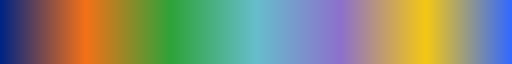

In [147]:
#Design colormap
mycolors2 = ["#002484","#f57118"]
mycolors3 = ["#002484","#f57118","#2ea339"]
mycolors4 = ["#002484","#f57118","#2ea339","#66becc"]
mycolors5 = ["#002484","#f57118","#2ea339","#66becc","#8d70cc"] ##3369ff or #002484
mycolors7 = ["#002484","#f57118","#2ea339","#66becc","#8d70cc","#f5c814","#3369ff"]
mycolors9 = ["#002484","#f57118","#2ea339","#66becc","#8d70cc","#f5c814","#3369ff","#ea2127","#333338"]
mycolors_heatmap = ["#002484","#66becc","#8d70cc","#f57118"]
sns.set_palette(mycolors7)
mycmap2 = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors2)
mycmap3 = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors3)
mycmap4 = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors4)
mycmap5 = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors5)
mycmap7 = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors7)
mycmap9 = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors9)
mycmap_heatmap = matplotlib.colors.LinearSegmentedColormap.from_list("", mycolors_heatmap)
mycmap7

## Import data

In [148]:
#File should be stored in subfolder 'data', which should be in the same main folder as the python notebook
widetable_corr = pd.read_csv('data/GCMS_widetable_corr_public.csv', dtype={'Sample': str})
widetable_corr = widetable_corr.set_index(['Category','Type','Sample','Replicate'])
widetable_corr

A    B  C  D    E  F    G    H  I  J  \
Category        Type Sample Replicate                                           
BLK             B    1      1          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
DC              R    272    1          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
                            2          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
                            3          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
                            4          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
...                                    ...  ... .. ..  ... ..  ...  ... .. ..   
IP              R    681    1          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
                            2          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
                            3          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
                            4          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   
Procedure blank B    1      1          0.0  0.0  0  0  0.0  0  0.0  0.0  0  0   

                                         K            L    M    N    O  ...  \
Category        Type Sample Replicate                                   ...   
BLK             B    1      1          0.0     0.000000  0.0  0.0  0.0  ...   
DC              R    272    1          0.0     0.000000  0.0  0.0  0.0  ...   
                            2          0.0  2188.385714  0.0  0.0  0.0  ...   
                            3          0.0     0.000000  0.0  0.0  0.0  ...   
                            4          0.0     0.000000  0.0  0.0  0.0  ...   
...                                    ...          ...  ...  ...  ...  ...   
IP              R    681    1          0.0     0.000000  0.0  0.0  0.0  ...   
                            2          0.0     0.000000  0.0  0.0  0.0  ...   
                            3          0.0     0.000000  0.0  0.0  0.0  ...   
                            4          0.0     0.000000  0.0  0.0  0.0  ...   
Procedure blank B    1      1          0.0   460.785714  0.0  0.0  0.0  ...   

                                       CQ      CR  CS  CT  CU   CV  \
Category        Type Sample Replicate                                
BLK             B    1      1           0     0.0   0   0   0  0.0   
DC              R    272    1           0   591.4   0   0   0  0.0   
                            2           0  1443.0   0   0   0  0.0   
                            3           0   593.9   0   0   0  0.0   
                            4           0   600.0   0   0   0  0.0   
...                                    ..     ...  ..  ..  ..  ...   
IP              R    681    1           0     0.0   0   0   0  0.0   
                            2           0     0.0   0   0   0  0.0   
                            3           0     0.0   0   0   0  0.0   
                            4           0     0.0   0   0   0  0.0   
Procedure blank B    1      1           0     0.0   0   0   0  0.0   

                                                CW  CX   CY   CZ  DA  \
Category        Type Sample Replicate                                  
BLK             B    1      1             0.000000   0  0.0  0.0   0   
DC              R    272    1          2198.942857   0  0.0  0.0   0   
                            2             0.000000   0  0.0  0.0   0   
                            3           459.642857   0  0.0  0.0   0   
                            4           704.942857   0  0.0  0.0   0   
...                                            ...  ..  ...  ...  ..   
IP              R    681    1             0.000000   0  0.0  0.0   0   
                            2             0.000000   0  0.0  0.0   0   
                            3             0.000000   0  0.0  0.0   0   
                            4             0.000000   0  0.0  0.0   0   
Procedure blank B    1      1             0.000000   0  0.0  0.0   0   

                                               DB   DC           DD  DE  
Category        Type Sample Replicate

## Percentages

In [149]:
# Row-wise percentages: each value divided by the sum of its row * 100
widetable_corr_pct = widetable_corr.div(widetable_corr.sum(axis=1), axis=0) * 100
widetable_corr_pct

A    B    C    D    E    F    G    H  \
Category        Type Sample Replicate                                           
BLK             B    1      1          NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
DC              R    272    1          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
                            2          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
                            3          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
                            4          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
...                                    ...  ...  ...  ...  ...  ...  ...  ...   
IP              R    681    1          NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
                            2          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
                            3          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
                            4          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
Procedure blank B    1      1          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

                                         I    J    K          L    M    N  \
Category        Type Sample Replicate                                       
BLK             B    1      1          NaN  NaN  NaN        NaN  NaN  NaN   
DC              R    272    1          0.0  0.0  0.0   0.000000  0.0  0.0   
                            2          0.0  0.0  0.0   0.453608  0.0  0.0   
                            3          0.0  0.0  0.0   0.000000  0.0  0.0   
                            4          0.0  0.0  0.0   0.000000  0.0  0.0   
...                                    ...  ...  ...        ...  ...  ...   
IP              R    681    1          NaN  NaN  NaN        NaN  NaN  NaN   
                            2          0.0  0.0  0.0   0.000000  0.0  0.0   
                            3          0.0  0.0  0.0   0.000000  0.0  0.0   
                            4          0.0  0.0  0.0   0.000000  0.0  0.0   
Procedure blank B    1      1          0.0  0.0  0.0  13.501691  0.0  0.0   

                                         O  ...   CQ        CR   CS   CT   CU  \
Category        Type Sample Replicate       ...                                 
BLK             B    1      1          NaN  ...  NaN       NaN  NaN  NaN  NaN   
DC              R    272    1          0.0  ...  0.0  0.362664  0.0  0.0  0.0   
                            2          0.0  ...  0.0  0.299105  0.0  0.0  0.0   
                            3          0.0  ...  0.0  0.363854  0.0  0.0  0.0   
                            4          0.0  ...  0.0  0.369297  0.0  0.0  0.0   
...                                    ...  ...  ...       ...  ...  ...  ...   
IP              R    681    1          NaN  ...  NaN       NaN  NaN  NaN  NaN   
                            2          0.0  ...  0.0  0.000000  0.0  0.0  0.0   
                            3          0.0  ...  0.0  0.000000  0.0  0.0  0.0   
                            4          0.0  ...  0.0  0.000000  0.0  0.0  0.0   
Procedure blank B    1      1          0.0  ...  0.0  0.000000  0.0  0.0  0.0   

                                        CV        CW   CX   CY   CZ   DA  \
Category        Type Sample Replicate                                      
BLK             B    1      1          NaN       NaN  NaN  NaN  NaN  NaN   
DC              R    272    1          0.0  1.348456  0.0  0.0  0.0  0.0   
                            2          0.0  0.000000  0.0  0.0  0.0  0.0   
                            3          0.0  0.281601  0.0  0.0  0.0  0.0   
                            4          0.0  0.433889  0.0  0.0  0.0  0.0   
...                                    ...       ...  ...  ...  ...  ...   
IP              R    681    1          NaN       NaN  NaN  NaN  NaN  NaN   
                            2          0.0  0.000000  0.0  0.0  0.0  0.0   
                            3          0.0  0.000000  0.0  0.0  0.0  0.0   
                            4          0.0  0.000000  0.0  0.0  0.0  0.0   
Procedure blank B  

## Wide table groups

### DIMP

All samples

In [150]:
widetable_DI = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI = widetable_DI.loc[:, (widetable_DI != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\696509548.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI')]


Unknown DIMP samples

In [151]:
widetable_DI_U = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_U = widetable_DI_U.loc[:, (widetable_DI_U != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\1780929737.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\1780929737.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U')]


Reference DIMP Samples

In [152]:
widetable_DI_R = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'R')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_R = widetable_DI_R.loc[:, (widetable_DI_R != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\218469018.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'R')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\218469018.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'R')]


Likelihood ratio datasets

In [153]:
widetable_DI_LR1 = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Sample'] == '356') | (widetable_corr.reset_index()['Sample'] == '876')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_LR1 = widetable_DI_LR1.loc[:, (widetable_DI_LR1 != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\2695156275.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '356') | (widetable_corr.reset_index()['Sample'] == '876')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\2695156275.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '356') | (widetable_corr.reset_index()['Sample'] == '876')]


In [154]:
widetable_DI_LR2 = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Sample'] == '356') | (widetable_corr.reset_index()['Sample'] == '361')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_LR2 = widetable_DI_LR2.loc[:, (widetable_DI_LR2 != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\2293038633.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '356') | (widetable_corr.reset_index()['Sample'] == '361')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\2293038633.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '356') | (widetable_corr.reset_index()['Sample'] == '361')]


In [155]:
widetable_DI_LR3 = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Sample'] == '064') | (widetable_corr.reset_index()['Sample'] == '561')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_LR3 = widetable_DI_LR3.loc[:, (widetable_DI_LR3 != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\2042004385.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '064') | (widetable_corr.reset_index()['Sample'] == '561')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\2042004385.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '064') | (widetable_corr.reset_index()['Sample'] == '561')]


In [156]:
widetable_DI_LR3_ref = (widetable_DI
                    .reset_index()
                    .drop(widetable_DI.reset_index()[(widetable_DI.reset_index()['Sample'] == '064') | 
                                                     (widetable_DI.reset_index()['Sample'] == '356') | 
                                                     (widetable_DI.reset_index()['Sample'] == '361') | 
                                                     (widetable_DI.reset_index()['Sample'] == '561')].index)
                    ).set_index(['Category','Type','Sample','Replicate'])

In [157]:
widetable_DI_LR4 = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Sample'] == '361') | (widetable_corr.reset_index()['Sample'] == '433')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_LR4 = widetable_DI_LR4.loc[:, (widetable_DI_LR4 != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\1441409824.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '361') | (widetable_corr.reset_index()['Sample'] == '433')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\1441409824.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '361') | (widetable_corr.reset_index()['Sample'] == '433')]


In [158]:
widetable_DI_LR4_ref = (widetable_DI
                    .reset_index()
                    .drop(widetable_DI.reset_index()[(widetable_DI.reset_index()['Sample'] == '064') | 
                                                     (widetable_DI.reset_index()['Sample'] == '356') | 
                                                     (widetable_DI.reset_index()['Sample'] == '361') | 
                                                     (widetable_DI.reset_index()['Sample'] == '433')].index)
                    ).set_index(['Category','Type','Sample','Replicate'])

In [159]:
widetable_DI_LR5 = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Sample'] == '067') | (widetable_corr.reset_index()['Sample'] == '893')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_LR5 = widetable_DI_LR5.loc[:, (widetable_DI_LR5 != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\931795800.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '067') | (widetable_corr.reset_index()['Sample'] == '893')]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\931795800.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Sample'] == '067') | (widetable_corr.reset_index()['Sample'] == '893')]


In [160]:
widetable_DI_LR5_ref = (widetable_DI
                    .reset_index()
                    .drop(widetable_DI.reset_index()[(widetable_DI.reset_index()['Sample'] == '067') | 
                                                     (widetable_DI.reset_index()['Sample'] == '893') | 
                                                     (widetable_DI.reset_index()['Sample'] == '361') |
                                                     (widetable_DI.reset_index()['Sample'] == '876') | 
                                                     (widetable_DI.reset_index()['Sample'] == '064')].index)
                    ).set_index(['Category','Type','Sample','Replicate'])

### DC

In [161]:
widetable_DC = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'DC')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DC = widetable_DC.loc[:, (widetable_DC != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\454207124.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DC')]


In [162]:
widetable_DI_DC = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'DC') | ((widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U'))]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_DC = widetable_DI_DC.loc[:, (widetable_DI_DC != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\4268557122.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DC') | ((widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U'))]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\4268557122.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'DC') | ((widetable_corr.reset_index()['Category'] == 'DI') & (widetable

### IPA

In [163]:
widetable_IP = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'IP')]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_IP = widetable_IP.loc[:, (widetable_IP != 0).sum() >= 2].round(1)

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\1676122985.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'IP')]


In [164]:
widetable_DI_IPA = (widetable_corr
                .reset_index()[(widetable_corr.reset_index()['Category'] == 'IP') | ((widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U'))]
                .set_index(['Category','Type','Sample','Replicate'])
                )
# Drop columns with fewer than 2 nonzero values
widetable_DI_IPA = widetable_DI_IPA.loc[:, (widetable_DI_IPA != 0).sum() >= 2]

C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\532139799.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'IP') | ((widetable_corr.reset_index()['Category'] == 'DI') & (widetable_corr.reset_index()['Type'] == 'U'))]
C:\Users\hoegeejm\AppData\Local\Temp\ipykernel_23788\532139799.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()[(widetable_corr.reset_index()['Category'] == 'IP') | ((widetable_corr.reset_index()['Category'] == 'DI') & (widetable_c

## Visualization

#### Number of compounds

Number of compounds for each replicate or sample

In [165]:
widetable_count = widetable_corr[[]].copy()
widetable_count['n_compounds'] = (widetable_corr.select_dtypes(include='number') != 0).sum(axis=1)

In [166]:
widetable_count_mean = widetable_count.groupby(['Category','Type','Sample'], as_index=False)['n_compounds'].mean().round(1).sort_values('n_compounds')
widetable_count_mean

,Category,Type,Sample,n_compounds
0,BLK,B,1,0.0
19,IP,R,681,2.0
17,IP,R,313,2.8
8,DI,R,433,3.0
18,IP,R,666,3.0
15,IP,R,054,4.2
13,DI,U,361,4.8
20,Procedure blank,B,1,6.0
10,DI,R,893,7.5
7,DI,R,184,10.5


#### Heatmap

In [167]:
widetable_DI_DC_mean = widetable_DI_DC.groupby(['Category','Type','Sample']).mean()

In [168]:
widetable_DI_IPA_mean = widetable_DI_IPA.groupby(['Category','Type','Sample']).mean()

In [169]:
# Keep only columns present at least once in both Type=R and Type=U
cols_in_R = widetable_DI_DC.xs('R', level='Type').columns[(widetable_DI_DC.xs('R', level='Type') != 0).any()]
cols_in_U = widetable_DI_DC.xs('U', level='Type').columns[(widetable_DI_DC.xs('U', level='Type') != 0).any()]
cols_both = cols_in_R.intersection(cols_in_U)
widetable_DI_DC_select = widetable_DI_DC[cols_both]

In [170]:
widetable_DI_DC_select_mean = widetable_DI_DC_select.groupby(['Category','Type','Sample']).mean().round(1)

In [171]:
# Keep only columns present at least once in both Type=R and Type=U
cols_in_R = widetable_DI_IPA.xs('R', level='Type').columns[(widetable_DI_IPA.xs('R', level='Type') != 0).any()]
cols_in_U = widetable_DI_IPA.xs('U', level='Type').columns[(widetable_DI_IPA.xs('U', level='Type') != 0).any()]
cols_both = cols_in_R.intersection(cols_in_U)
widetable_DI_IPA_select = widetable_DI_IPA[cols_both]

In [172]:
widetable_DI_IPA_select_mean = widetable_DI_IPA_select.groupby(['Category','Type','Sample']).mean().round(1)

c:\Scripts\Icarus\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


<Axes: xlabel='Category-Type-Sample'>

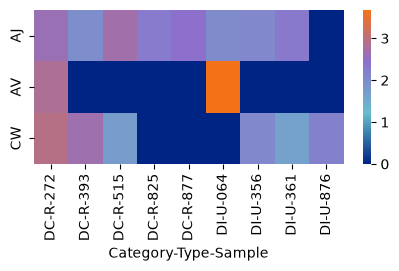

In [173]:
f, ax = plt.subplots(figsize=(5, 2))
sns.heatmap(np.log10(widetable_DI_DC_select_mean.T).replace([np.nan, -np.inf], 0), annot=False, linewidths=0, ax=ax, cmap=mycmap_heatmap)

#plt.savefig('img/Heatmap_DI_DC.svg', transparent=True, bbox_inches='tight')

c:\Scripts\Icarus\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


<Axes: xlabel='Category-Type-Sample'>

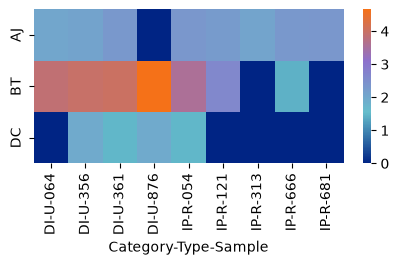

In [174]:
f, ax = plt.subplots(figsize=(5, 2))
sns.heatmap(np.log10(widetable_DI_IPA_select_mean.T).replace([np.nan, -np.inf], 0), annot=False, linewidths=0, ax=ax, cmap=mycmap_heatmap)

#plt.savefig('img/Heatmap_DI_IPA.svg', transparent=True, bbox_inches='tight')

## Data analysis

### PCA DI U

PCA of unknown DIMP samples

In [175]:
pca_diu = PCA()

class NoOpTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X
    
p_diu = Pipeline([('scaler', NoOpTransformer()), ('pca', pca_diu)])
p_diu['pca']

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [176]:
results_diu = dict(
    no_preprocessing = Pipeline([('scaler', NoOpTransformer()), ('pca', pca_diu)]),
    StandardScaler   = Pipeline([('scaler', StandardScaler()), ('pca', pca_diu)]),
    RobustScaler   = Pipeline([('scaler', RobustScaler()), ('pca', pca_diu)]),
    MinMaxScaler   = Pipeline([('scaler', MinMaxScaler()), ('pca', pca_diu)]),
    MaxAbsScaler   = Pipeline([('scaler', MaxAbsScaler()), ('pca', pca_diu)]),
    QuantileTransformer   = Pipeline([('scaler', QuantileTransformer(n_quantiles=3)), ('pca', pca_diu)]), #You can edit the number of quantiles that will be used.
    Normalizer   = Pipeline([('scaler', Normalizer()), ('pca', pca_diu)]))

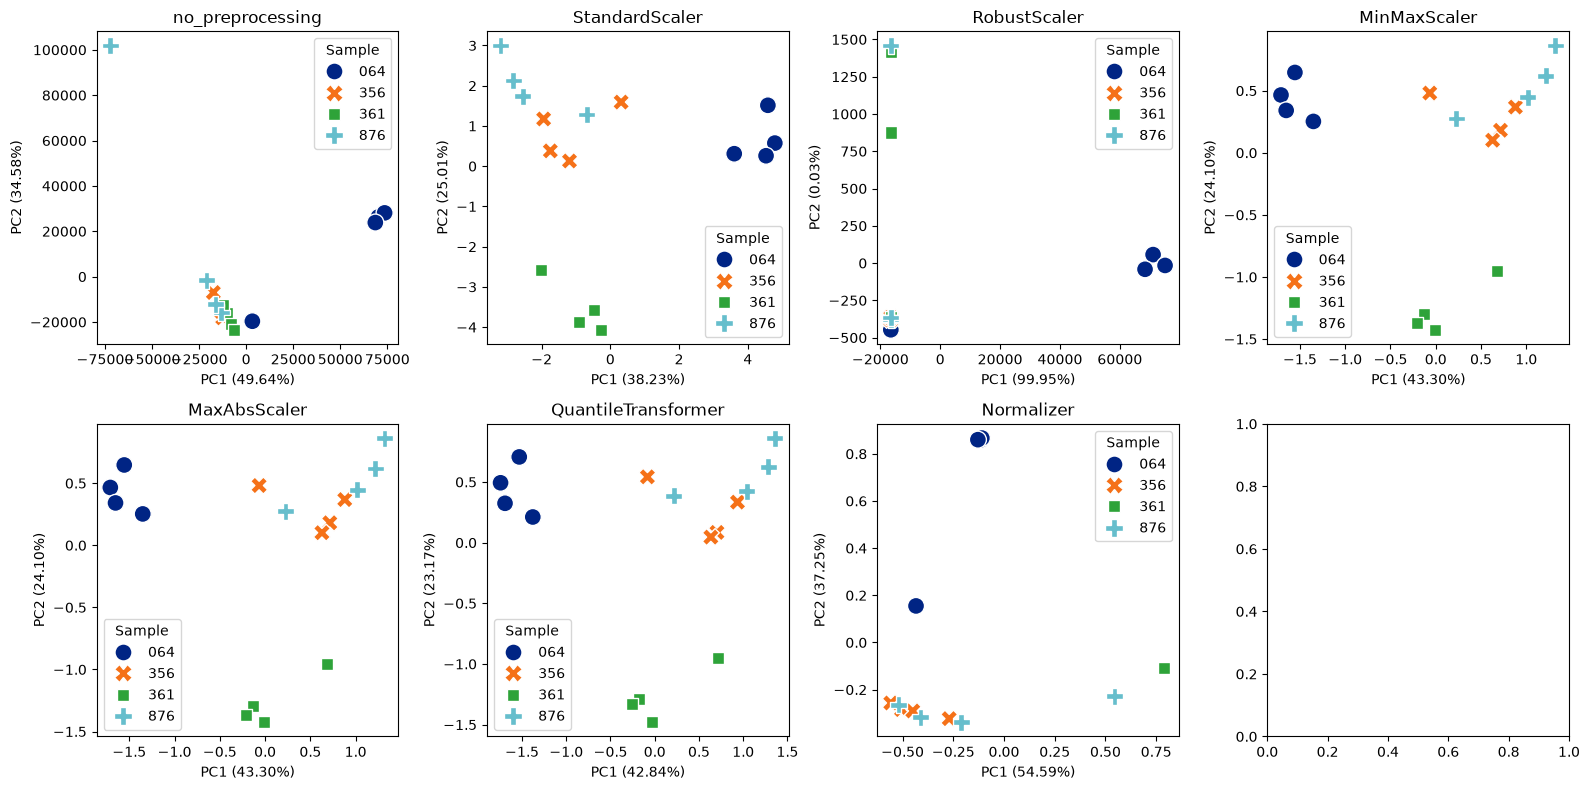

In [177]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16,8), layout="tight")
for (label, result), ax in zip(results_diu.items(), axs.flatten()):
    model = result.fit(widetable_DI_U)
    data = pd.DataFrame(model.transform(widetable_DI_U), index=widetable_DI_U.index).reset_index()
    sns.scatterplot(data=data, x=0, y=1, hue='Sample', style="Sample", s=150, legend=False, ax=ax)
    ax.set(title=label, xlabel=f"PC1 ({model['pca'].explained_variance_ratio_[0]:.2%})", ylabel=f"PC2 ({model['pca'].explained_variance_ratio_[1]:.2%})")
    sns.scatterplot(data=data, x=0, y=1, hue='Sample', style="Sample", s=150, legend=True, ax=ax)

In [178]:
pca_data_scaled_diu = pd.DataFrame(StandardScaler().fit_transform(widetable_DI_U), index=widetable_DI_U.index)

pca_diu = PCA()
pca_data_diu= pd.DataFrame(
    pca_diu.fit_transform(pca_data_scaled_diu), 
    index=widetable_DI_U.index
)

#### Score plot

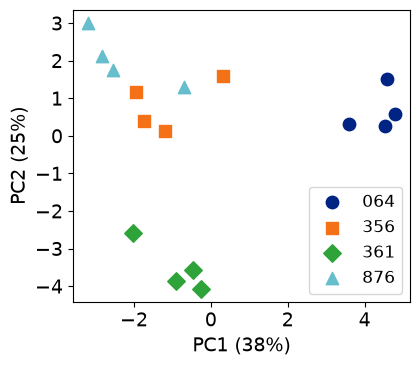

In [179]:
plt.figure(figsize=(4.5, 4))

categories_diu = pca_data_diu.reset_index()['Sample'].unique()
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

for i, cat in enumerate(categories_diu):
    subset = pca_data_diu.loc[pca_data_diu.index.get_level_values('Sample') == cat]
    plt.scatter(subset[0], subset[1], marker=markers[i % len(markers)], label=cat, s=80,
                color=mycolors7[i % len(mycolors7)])

plt.xlabel(f'PC1 ({pca_diu.explained_variance_ratio_[0]:.0%})', fontsize=14)
plt.ylabel(f'PC2 ({pca_diu.explained_variance_ratio_[1]:.0%})', fontsize=14)

plt.legend(fontsize=12, loc='lower right') #, bbox_to_anchor=(1, 0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gcf().subplots_adjust(bottom=0.15, left=0.15)

#plt.savefig('img/PCA_DIMP_U.svg', transparent=True)

#### Loadings

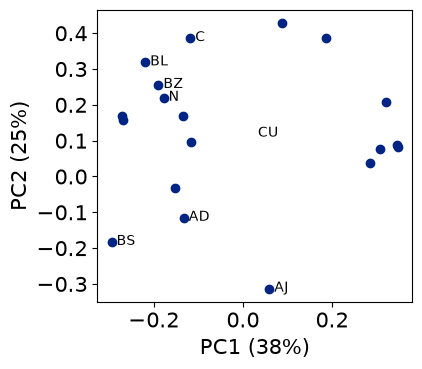

In [180]:
plt.figure(figsize=(4.5, 4))

loadings_diu = pd.DataFrame(pca_diu.components_, columns=widetable_DI_U.columns).T[[0, 1]]

plt.scatter(loadings_diu[0], loadings_diu[1])
plt.xlabel(f'PC1 ({pca_diu.explained_variance_ratio_[0]:.0%})', fontsize=15)
plt.ylabel(f'PC2 ({pca_diu.explained_variance_ratio_[1]:.0%})', fontsize=15)
for label, x, y in loadings_diu.itertuples():
    if y < -0.1:
       plt.annotate(label, (x, y), xytext=(5, -3), textcoords='offset pixels', fontsize=10)
    if x > 0.347:
       plt.annotate(label, (x, y), xytext=(-140, 10), textcoords='offset pixels', fontsize=10)
    if x < -0.1 and y>0.17:
       plt.annotate(label, (x, y), xytext=(5, -3), textcoords='offset pixels', fontsize=10)
   #  # if x > 0.2 and x < 0.3:
   #  #    plt.annotate(label, (x, y), xytext=(5, -3), textcoords='offset pixels', fontsize=10)
   #  if abs(x) > 0.5:
   #     plt.annotate(label, (x, y), xytext=(-115, 12), textcoords='offset pixels', fontsize=10)
   #  if abs(x) > 0.47 and x < 0.5:
   #     plt.annotate(label, (x, y), xytext=(-150, -10), textcoords='offset pixels', fontsize=10)
   #  if abs(x) > 0.45 and x < 0.47:
   #     plt.annotate(label, (x, y), xytext=(-50, 5), textcoords='offset pixels', fontsize=10)
   #  # if abs(x) > 0.4 and x < 0.45:
   #  #    plt.annotate(label, (x, y), xytext=(-70, 5), textcoords='offset pixels', fontsize=10)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gcf().subplots_adjust(left=0.2, bottom=0.15)

#plt.savefig('img/PCA_DIMP_U_loadings.svg', transparent=True)

#### LOO validation

Leave one out validation

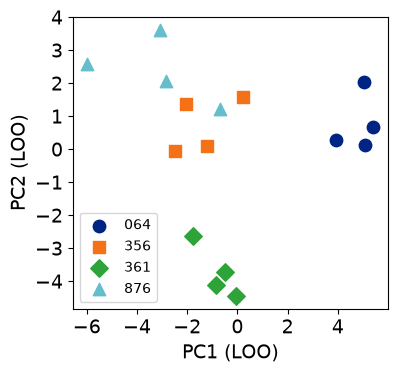

In [181]:
scaler_diu = StandardScaler()
pca_loo_diu = PCA(n_components=2)

loo = LeaveOneOut()
X_loo = widetable_DI_U.values
y_loo = widetable_DI_U.index.get_level_values('Sample')

loo_scores = []

for train_idx, test_idx in loo.split(X_loo):
    X_train = scaler_diu.fit_transform(X_loo[train_idx])
    X_test = scaler_diu.transform(X_loo[test_idx])
    
    pca_loo_diu.fit(X_train)
    score = pca_loo_diu.transform(X_test)
    
    loo_scores.append({
        'PC1': score[0, 0],
        'PC2': score[0, 1],
        'Sample': y_loo[test_idx[0]],
        'Replicate': widetable_DI_U.index.get_level_values('Replicate')[test_idx[0]],
    })

loo_df = pd.DataFrame(loo_scores)

# Plot
plt.figure(figsize=(4.5, 4))
samples_loo = loo_df['Sample'].unique()
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

for i, sample in enumerate(samples_loo):
    subset = loo_df[loo_df['Sample'] == sample]
    plt.scatter(subset['PC1'], subset['PC2'],
                marker=markers[i % len(markers)],
                label=sample, s=80, color=mycolors7[i % len(mycolors7)])

plt.xlabel('PC1 (LOO)', fontsize=14)
plt.ylabel('PC2 (LOO)', fontsize=14)
plt.legend(fontsize=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gcf().subplots_adjust(bottom=0.15, left=0.2)

#plt.savefig('img/PCA_DIU_LOO.svg', transparent=True)


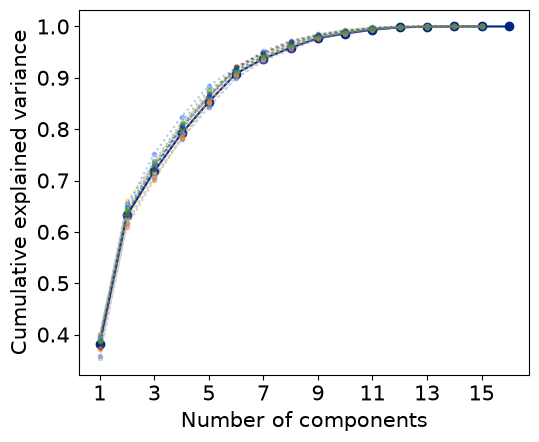

In [182]:
pca_diu = PCA()
scaler_loo_diu = StandardScaler()

plt.figure(figsize=(6, 5))

# Full dataset (scaled)
X_scaled_full = scaler_loo_diu.fit_transform(widetable_DI_U)
pca_diu.fit(X_scaled_full)
n_comp = len(pca_diu.explained_variance_ratio_)
plt.plot(range(1, n_comp + 1), np.cumsum(pca_diu.explained_variance_ratio_), marker='o', label='All data')

markup = dict(fontsize=15)

for leaveout in widetable_DI_U.index:
    X_loo = widetable_DI_U.drop(leaveout)
    X_loo_scaled = scaler_loo_diu.fit_transform(X_loo)
    pca_diu.fit(X_loo_scaled)
    n_comp_loo = len(pca_diu.explained_variance_ratio_)
    plt.plot(
        range(1, n_comp_loo + 1),
        np.cumsum(pca_diu.explained_variance_ratio_), 
        alpha=.4, 
        ls=':',
        marker='.'
    )

plt.xlabel("Number of components", **markup)
plt.ylabel("Cumulative explained variance", **markup)
plt.xticks(np.arange(1, 16, step=2), **markup)
plt.yticks(**markup)
plt.gcf().subplots_adjust(bottom=0.15, left=0.15)

#plt.savefig('img/PCA_DIU_LOOcum.svg', transparent=True)

### PCA DI

PCA of all DIMP samples

In [183]:
pca_di = PCA()

results_di = dict(
    no_preprocessing = Pipeline([('scaler', NoOpTransformer()), ('pca', pca_di)]),
    StandardScaler   = Pipeline([('scaler', StandardScaler()), ('pca', pca_di)]),
    RobustScaler   = Pipeline([('scaler', RobustScaler()), ('pca', pca_di)]),
    MinMaxScaler   = Pipeline([('scaler', MinMaxScaler()), ('pca', pca_di)]),
    MaxAbsScaler   = Pipeline([('scaler', MaxAbsScaler()), ('pca', pca_di)]),
    QuantileTransformer   = Pipeline([('scaler', QuantileTransformer(n_quantiles=3)), ('pca', pca_di)]), #You can edit the number of quantiles that will be used.
    Normalizer   = Pipeline([('scaler', Normalizer()), ('pca', pca_di)]))

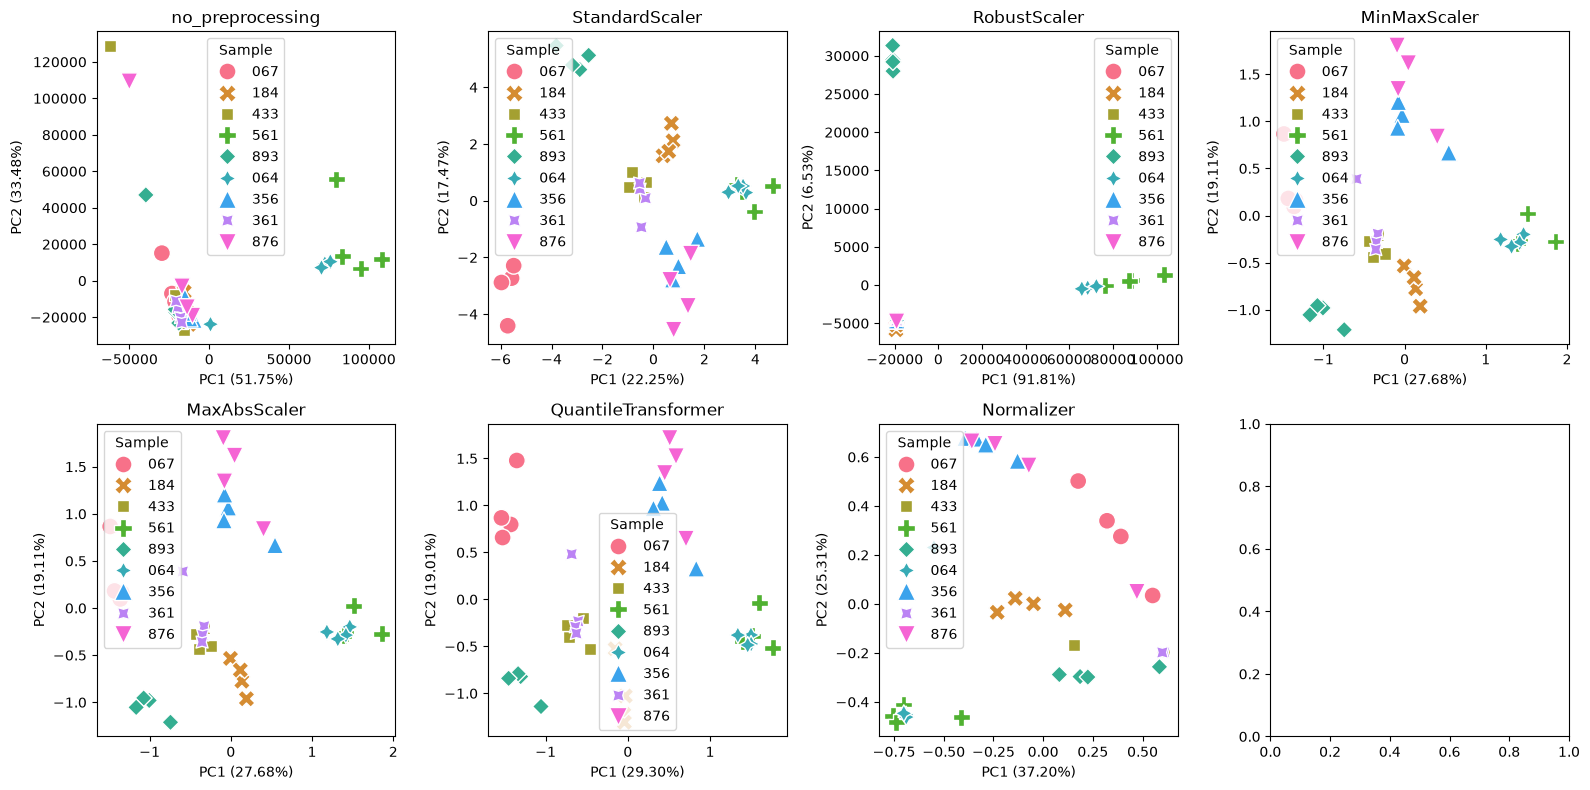

In [184]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16,8), layout="tight")
for (label, result), ax in zip(results_di.items(), axs.flatten()):
    model = result.fit(widetable_DI)
    data = pd.DataFrame(model.transform(widetable_DI), index=widetable_DI.index).reset_index()
    sns.scatterplot(data=data, x=0, y=1, hue='Sample', style="Sample", s=150, legend=False, ax=ax)
    ax.set(title=label, xlabel=f"PC1 ({model['pca'].explained_variance_ratio_[0]:.2%})", ylabel=f"PC2 ({model['pca'].explained_variance_ratio_[1]:.2%})")
    sns.scatterplot(data=data, x=0, y=1, hue='Sample', style="Sample", s=150, legend=True, ax=ax)

In [185]:
pca_data_scaled_di = pd.DataFrame(StandardScaler().fit_transform(widetable_DI), index=widetable_DI.index)

pca_di = PCA()
pca_data_di= pd.DataFrame(
    pca_di.fit_transform(pca_data_scaled_di), 
    index=widetable_DI.index
)

#### Score plot

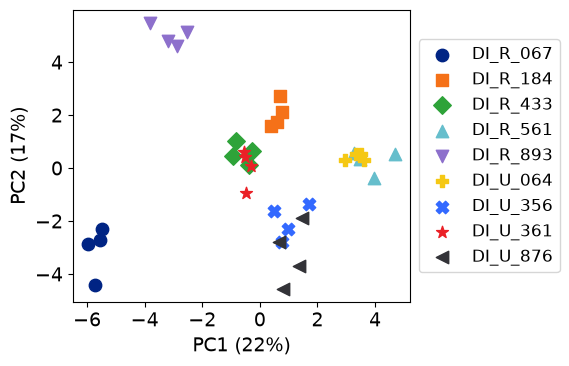

In [186]:
plt.figure(figsize=(4.5, 4))

categories_di = pca_data_di.reset_index()['Sample'].unique()
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*', '<']

for i, cat in enumerate(categories_di):
    subset = pca_data_di.loc[pca_data_di.index.get_level_values('Sample') == cat]
    # Build legend label from full index: Category_Type_Sample
    cat_val = subset.index.get_level_values('Category')[0]
    type_val = subset.index.get_level_values('Type')[0]
    legend_label = f"{cat_val}_{type_val}_{cat}"
    plt.scatter(subset[0], subset[1], marker=markers[i % len(markers)], label=legend_label, s=80,
                color=mycolors9[i % len(mycolors9)])

plt.xlabel(f'PC1 ({pca_di.explained_variance_ratio_[0]:.0%})', fontsize=14)
plt.ylabel(f'PC2 ({pca_di.explained_variance_ratio_[1]:.0%})', fontsize=14)

plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gcf().subplots_adjust(bottom=0.15, left=0.15)

#plt.savefig('img/GCMS_PCA_DIMP.svg', transparent=True, bbox_inches='tight')

#### Loadings

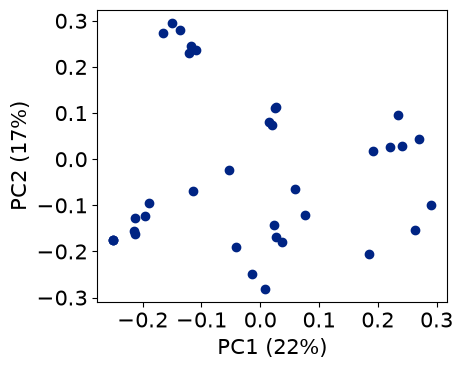

In [187]:
plt.figure(figsize=(5, 4))

loadings_di = pd.DataFrame(pca_di.components_, columns=widetable_DI.columns).T[[0, 1]]

plt.scatter(loadings_di[0], loadings_di[1])
plt.xlabel(f'PC1 ({pca_di.explained_variance_ratio_[0]:.0%})', fontsize=15)
plt.ylabel(f'PC2 ({pca_di.explained_variance_ratio_[1]:.0%})', fontsize=15)
# for label, x, y in loadings.itertuples():
   #  if abs(y) > 0.557 or y<-0.08:
   #     plt.annotate(label, (x, y), xytext=(5, -3), textcoords='offset pixels', fontsize=10)
   #  if abs(y) < 0.557 and y > 0.5:
   #     plt.annotate(label, (x, y), xytext=(-5, -17), textcoords='offset pixels', fontsize=10)
   #  # if x > 0.2 and x < 0.3:
   #  #    plt.annotate(label, (x, y), xytext=(5, -3), textcoords='offset pixels', fontsize=10)
   #  if abs(x) > 0.5:
   #     plt.annotate(label, (x, y), xytext=(-115, 12), textcoords='offset pixels', fontsize=10)
   #  if abs(x) > 0.47 and x < 0.5:
   #     plt.annotate(label, (x, y), xytext=(-150, -10), textcoords='offset pixels', fontsize=10)
   #  if abs(x) > 0.45 and x < 0.47:
   #     plt.annotate(label, (x, y), xytext=(-50, 5), textcoords='offset pixels', fontsize=10)
   #  # if abs(x) > 0.4 and x < 0.45:
   #  #    plt.annotate(label, (x, y), xytext=(-70, 5), textcoords='offset pixels', fontsize=10)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gcf().subplots_adjust(left=0.2, bottom=0.15)

#plt.savefig('img/PCA_LCMS_category_loadings.svg', transparent=True)

#### LOO validation

Leave one out validation

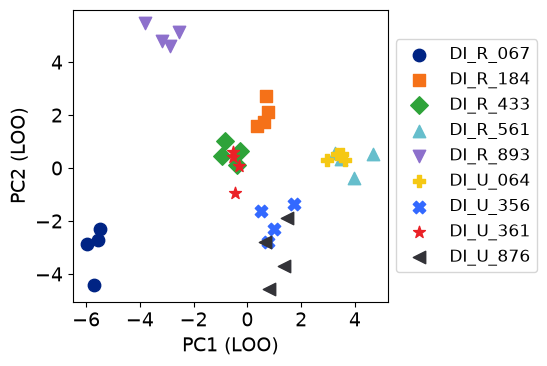

In [188]:
scaler_di = StandardScaler()
pca_loo_di = PCA(n_components=2)

loo = LeaveOneOut()
X_loo = widetable_DI.values
y_loo = widetable_DI.index.get_level_values('Sample')

loo_scores = []

for train_idx, test_idx in loo.split(X_loo):
    X_train = scaler_di.fit_transform(X_loo[train_idx])
    X_test = scaler_di.transform(X_loo[test_idx])
    
    pca_loo_di.fit(X_train)
    score = pca_loo_di.transform(X_test)
    
    loo_scores.append({
        'PC1': score[0, 0],
        'PC2': score[0, 1],
        'Sample': y_loo[test_idx[0]],
        'Replicate': widetable_DI.index.get_level_values('Replicate')[test_idx[0]],
    })

loo_df = pd.DataFrame(loo_scores)

# Plot
plt.figure(figsize=(4.5, 4))
samples_loo = loo_df['Sample'].unique()
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*', '<']

for i, cat in enumerate(categories_di):
    subset = pca_data_di.loc[pca_data_di.index.get_level_values('Sample') == cat]
    # Build legend label from full index: Category_Type_Sample
    cat_val = subset.index.get_level_values('Category')[0]
    type_val = subset.index.get_level_values('Type')[0]
    legend_label = f"{cat_val}_{type_val}_{cat}"
    plt.scatter(subset[0], subset[1], marker=markers[i % len(markers)], label=legend_label, s=80,
                color=mycolors9[i % len(mycolors9)])

plt.xlabel('PC1 (LOO)', fontsize=14)
plt.ylabel('PC2 (LOO)', fontsize=14)
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gcf().subplots_adjust(bottom=0.15, left=0.2)

#plt.savefig('img/GCMS_PCA_DIMP_LOO.svg', transparent=True, bbox_inches='tight')

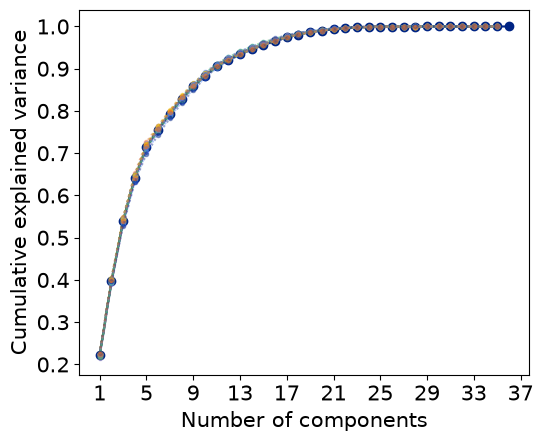

In [189]:
pca_di = PCA()
scaler_loo_di = StandardScaler()

plt.figure(figsize=(6, 5))

# Full dataset (scaled)
X_scaled_full = scaler_loo_di.fit_transform(widetable_DI)
pca_di.fit(X_scaled_full)
n_comp = len(pca_di.explained_variance_ratio_)
plt.plot(range(1, n_comp + 1), np.cumsum(pca_di.explained_variance_ratio_), marker='o', label='All data')

markup = dict(fontsize=15)

for leaveout in widetable_DI.index:
    X_loo = widetable_DI.drop(leaveout)
    X_loo_scaled = scaler_loo_di.fit_transform(X_loo)
    pca_di.fit(X_loo_scaled)
    n_comp_loo = len(pca_di.explained_variance_ratio_)
    plt.plot(
        range(1, n_comp_loo + 1),
        np.cumsum(pca_di.explained_variance_ratio_), 
        alpha=.4, 
        ls=':',
        marker='.'
    )

plt.xlabel("Number of components", **markup)
plt.ylabel("Cumulative explained variance", **markup)
plt.xticks(np.arange(1, 40, step=4), **markup)
plt.yticks(**markup)
plt.gcf().subplots_adjust(bottom=0.15, left=0.15)

#plt.savefig('img/GCMS_PCA_DIMP_LOOcum.svg', transparent=True)

### HCA

#### DI U

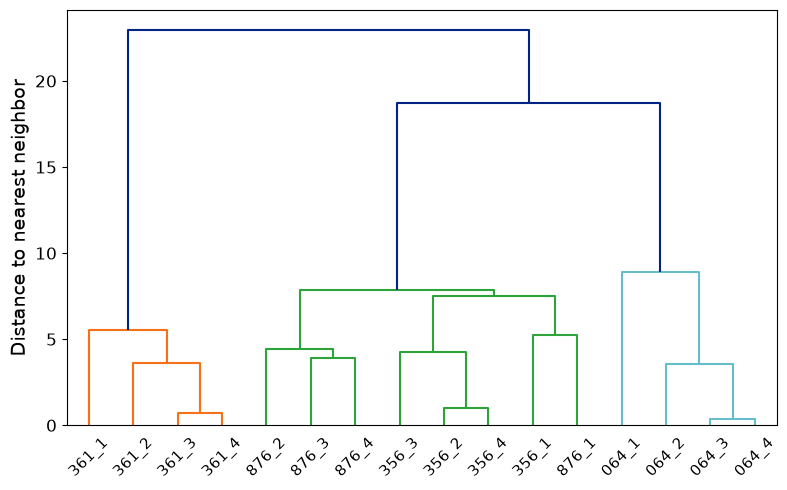

In [190]:
# Log10 transform to stabilise variance
X_hca = widetable_DI_U.apply(lambda x: np.log10(x + 1))

# Compute linkage (Ward's method on Euclidean distances)
Z_hca = linkage(X_hca, method='ward', metric='euclidean')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(8, 5))
labels_hca = [f"{s}_{r}" for _, _, s, r in X_hca.index]
dendrogram(Z_hca, labels=labels_hca, leaf_rotation=45, leaf_font_size=11, ax=ax)
ax.set_ylabel('Distance to nearest neighbor', fontsize=14)
#ax.set_title('HCA - DI-U samples', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

#plt.savefig('img/HCA_DIU_GCMS.svg', transparent=True)

#### DI

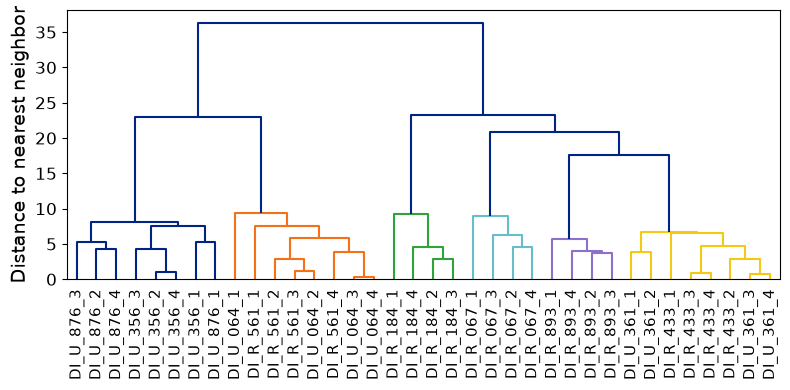

In [191]:
# Log10 transform to stabilise variance
X_hca = widetable_DI.apply(lambda x: np.log10(x + 1))

# Compute linkage (Ward's method on Euclidean distances)
Z_hca = linkage(X_hca, method='ward', metric='euclidean')

# Plot dendrogram with more colored subgroups
fig, ax = plt.subplots(figsize=(8, 4))
labels_hca = [f"{cat}_{t}_{s}_{r}" for cat, t, s, r in X_hca.index]
set_link_color_palette(mycolors9)
dendrogram(Z_hca, labels=labels_hca, leaf_rotation=90, leaf_font_size=11, ax=ax,
           color_threshold=0.4 * Z_hca[-1, 2])
set_link_color_palette(None)  # reset to default
ax.set_ylabel('Distance to nearest neighbor', fontsize=14)
#ax.set_title('HCA - DI samples', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

#plt.savefig('img/HCA_DI_GCMS.svg', transparent=True, bbox_inches='tight')


#### DI & DC

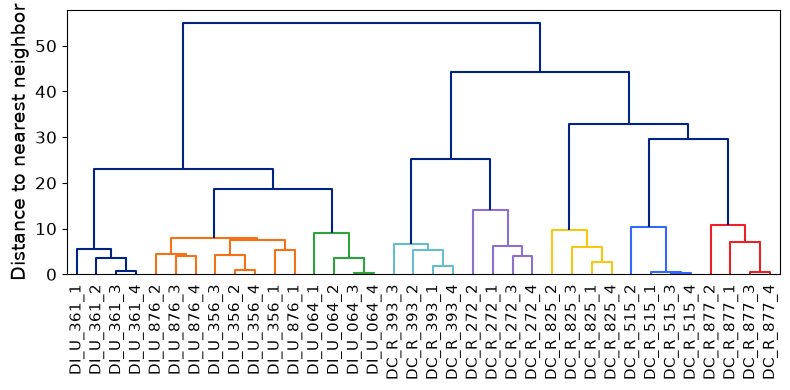

In [192]:
# Log10 transform to stabilise variance
X_hca = widetable_DI_DC.apply(lambda x: np.log10(x + 1))

# Compute linkage (Ward's method on Euclidean distances)
Z_hca = linkage(X_hca, method='ward', metric='euclidean')

# Plot dendrogram with more colored subgroups
fig, ax = plt.subplots(figsize=(8, 4))
labels_hca = [f"{cat}_{t}_{s}_{r}" for cat, t, s, r in X_hca.index]
set_link_color_palette(mycolors9)
dendrogram(Z_hca, labels=labels_hca, leaf_rotation=90, leaf_font_size=11, ax=ax,
           color_threshold=0.3 * Z_hca[-1, 2])
set_link_color_palette(None)  # reset to default
ax.set_ylabel('Distance to nearest neighbor', fontsize=14)
#ax.set_title('HCA - DI samples', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

#plt.savefig('img/HCA_DI_GCMS.svg', transparent=True, bbox_inches='tight')


#### DI & IP

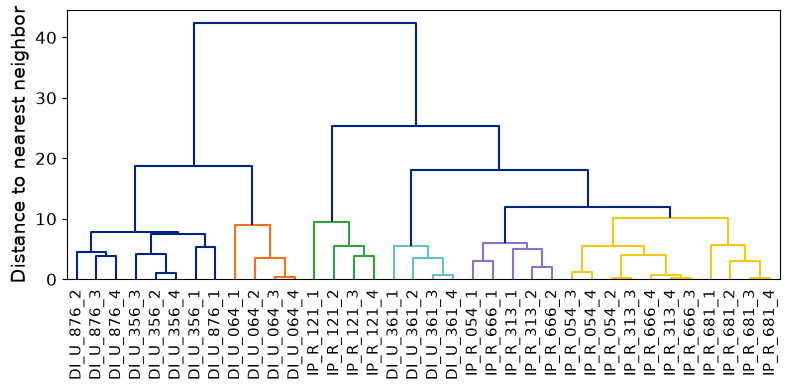

In [193]:
# Log10 transform to stabilise variance
X_hca = widetable_DI_IPA.apply(lambda x: np.log10(x + 1))

# Compute linkage (Ward's method on Euclidean distances)
Z_hca = linkage(X_hca, method='ward', metric='euclidean')

# Plot dendrogram with more colored subgroups
fig, ax = plt.subplots(figsize=(8, 4))
labels_hca = [f"{cat}_{t}_{s}_{r}" for cat, t, s, r in X_hca.index]
set_link_color_palette(mycolors9)
dendrogram(Z_hca, labels=labels_hca, leaf_rotation=90, leaf_font_size=11, ax=ax,
           color_threshold=0.25 * Z_hca[-1, 2])
set_link_color_palette(None)  # reset to default
ax.set_ylabel('Distance to nearest neighbor', fontsize=14)
#ax.set_title('HCA - DI samples', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

#plt.savefig('img/HCA_DI_GCMS.svg', transparent=True, bbox_inches='tight')


### Source comparison

#### Dataset 1

##### LR1

Cross-validated scores (leave-one-sample-out):
  Same-source pairs: 60
  Different-source pairs: 320

Cllr (KDE calibrator): 0.134


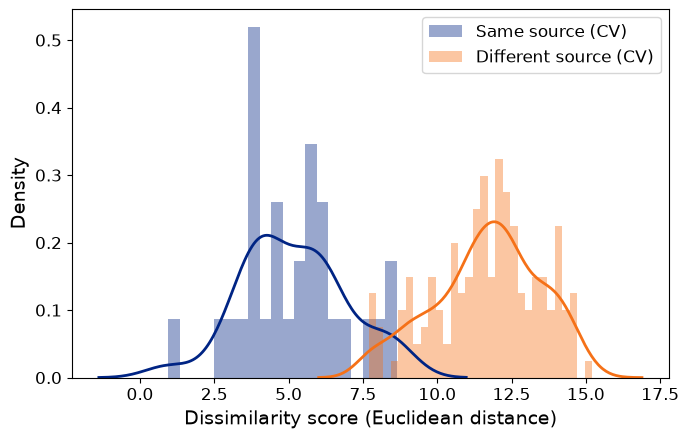

In [194]:
# Compute pairwise dissimilarity scores (Euclidean) with cross-validation
# Using leave-one-sample-out CV to avoid information leakage

# Aggregate: max area per compound for each Sample-Replicate
wt_dist = (widetable_DI_R
    .reset_index()
    .groupby(['Category', 'Type', 'Sample', 'Replicate'])
    .max()
)
wt_dist = wt_dist.apply(lambda x: np.log10(x + 1))

samples_dist = wt_dist.index.get_level_values('Sample').values
unique_samples = np.unique(samples_dist)

# Leave-one-sample-out CV: for each fold, hold out one sample
# Compute scores for held-out pairs using distributions from training pairs
all_same_scores = []
all_diff_scores = []
cv_same_scores = []
cv_diff_scores = []

for held_out in unique_samples:
    # Split into train and test
    test_mask = samples_dist == held_out
    train_mask = ~test_mask
    
    train_data = wt_dist[train_mask]
    test_data = wt_dist[test_mask]
    train_samples = samples_dist[train_mask]
    
    # Compute distances between test replicates and all training replicates
    for i, (idx_test, row_test) in enumerate(test_data.iterrows()):
        # Same-source: distance between test replicate and other replicates of same sample
        other_test = test_data.drop(index=idx_test)
        for idx_other, row_other in other_test.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_other.values)**2))
            cv_same_scores.append(d)
        
        # Different-source: distance between test replicate and training replicates
        for idx_train, row_train in train_data.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_train.values)**2))
            cv_diff_scores.append(d)

# Also compute full pairwise distances for comparison
dist_vec = pdist(wt_dist, metric='euclidean')
dist_mat = squareform(dist_vec)

n = len(samples_dist)
for i in range(n):
    for j in range(i + 1, n):
        d = dist_mat[i, j]
        if samples_dist[i] == samples_dist[j]:
            all_same_scores.append(d)
        else:
            all_diff_scores.append(d)

same_source = np.array(cv_same_scores)
diff_source = np.array(cv_diff_scores)

print(f"Cross-validated scores (leave-one-sample-out):")
print(f"  Same-source pairs: {len(same_source)}")
print(f"  Different-source pairs: {len(diff_source)}")

# Plot histogram + KDE
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(same_source, bins=20, density=True, alpha=0.4, color=mycolors2[0], label='Same source (CV)')
ax.hist(diff_source, bins=30, density=True, alpha=0.4, color=mycolors2[1], label='Different source (CV)')

sns.kdeplot(same_source, ax=ax, color=mycolors2[0], linewidth=2)
sns.kdeplot(diff_source, ax=ax, color=mycolors2[1], linewidth=2)

ax.set_xlabel('Dissimilarity score (Euclidean distance)', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
plt.tight_layout()

# Compute calibrated LRs using lir KDECalibrator (lir 1.6.0 API)
scores = np.concatenate([same_source, diff_source])
y_true = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])

# Create FeatureData with scores and labels
score_data = FeatureData(features=scores, labels=y_true)

# Fit KDE-based calibrator
cal = KDECalibrator(bandwidth='silverman')
cal.fit(score_data)

# Apply calibrator to get LLRs
llr_data = LLRData(**cal.apply(score_data).model_dump())

# Compute Cllr
cllr_value = compute_cllr(llr_data)
print(f"\nCllr (KDE calibrator): {cllr_value:.3f}")

#plt.savefig('img/dissimilarity_GCMS_hist_kde_CV_LR1.svg', transparent=True)

In [195]:
# === Step 6: Compare LR systems ===
# Using the CV dissimilarity scores computed above (same_source, diff_source)
# and SVM-based scores on DI-R paired data

# --- Prepare Euclidean distance score data ---
euclidean_scores = np.concatenate([same_source, diff_source])
euclidean_labels = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
euclidean_score_data = FeatureData(features=euclidean_scores, labels=euclidean_labels)

# --- Prepare SVM scores on DI-R pairs ---
# Create paired data from widetable_DI_R
wt_svm_lr = wt_dist.copy()
svm_source_ids = np.array(wt_svm_lr.index.get_level_values('Sample').values)

svm_features = wt_svm_lr.values
svm_fd = FeatureData(features=svm_features, source_ids=svm_source_ids)

instance_pairer = InstancePairing(ratio_limit=2)
svm_pairs = instance_pairer.pair(svm_fd)

# SVM pipeline: abs difference -> SVC -> probability to log odds
svm_scorer = LirPipeline([
    ('abs_difference', ElementWiseDifference()),
    ('classifier', SVC(probability=True)),
])
svm_scorer.fit(svm_pairs)
svm_score_data = svm_scorer.apply(svm_pairs)

print("=" * 60)
print("LR SYSTEM COMPARISON (Step 6)")
print("=" * 60)

# --- Define 4 LR systems ---
systems = {
    "Option 1: Euclidean + KDE": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 2: Euclidean + Logistic Regression": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
    "Option 3: SVM + KDE": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 4: SVM + Logistic Regression": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
}

# --- Evaluate each system ---
for name, system in systems.items():
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    
    sd = system["score_data"]
    calibrator = system["calibrator"]
    
    # Fit and apply calibrator
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    
    # Compute Cllr
    cllr_val = compute_cllr(lrs)
    print(f"  Cllr: {cllr_val:.4f}")
    
    # LR histogram
    # with show() as ax:
    #     ax.lr_histogram(lrs)
    #     ax.title(f'{name} - LR Histogram')
    
    # PAV plot
    # with show() as ax:
    #     ax.pav(lrs)
    #     ax.title(f'{name} - PAV plot')

print(f"\n{'=' * 60}")
print("SUMMARY")
print(f"{'=' * 60}")
for name, system in systems.items():
    sd = system["score_data"]
    calibrator = system["calibrator"]
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    cllr_val = compute_cllr(lrs)
    print(f"  {name:<45} Cllr = {cllr_val:.4f}")

LR SYSTEM COMPARISON (Step 6)

──────────────────────────────────────────────────
  Option 1: Euclidean + KDE
──────────────────────────────────────────────────
  Cllr: 0.1470

──────────────────────────────────────────────────
  Option 2: Euclidean + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1483

──────────────────────────────────────────────────
  Option 3: SVM + KDE
──────────────────────────────────────────────────
  Cllr: 0.0356

──────────────────────────────────────────────────
  Option 4: SVM + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1571

SUMMARY
  Option 1: Euclidean + KDE                     Cllr = 0.1470
  Option 2: Euclidean + Logistic Regression     Cllr = 0.1483
  Option 3: SVM + KDE                           Cllr = 0.0356
  Option 4: SVM + Logistic Regression           Cllr = 0.1571


c:\Scripts\Icarus\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Leave-one-sample-out CV for Euclidean distance + KDE + ELUB
  Fold (held out: 067): 6 same-source, 64 different-source pairs
  Fold (held out: 184): 6 same-source, 64 different-source pairs
  Fold (held out: 433): 6 same-source, 64 different-source pairs
  Fold (held out: 561): 6 same-source, 64 different-source pairs
  Fold (held out: 893): 6 same-source, 64 different-source pairs

  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)
  Cllr (LOSO-CV): 0.4610
  Total pairs: 350 (same: 30, diff: 320)


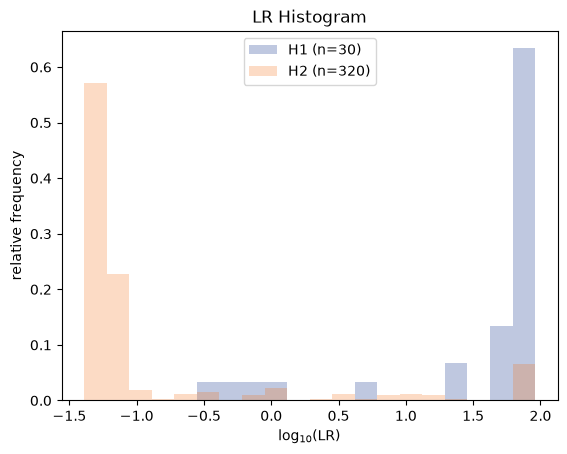

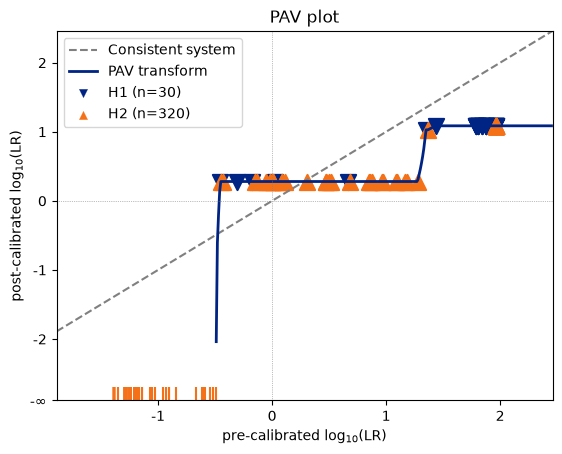

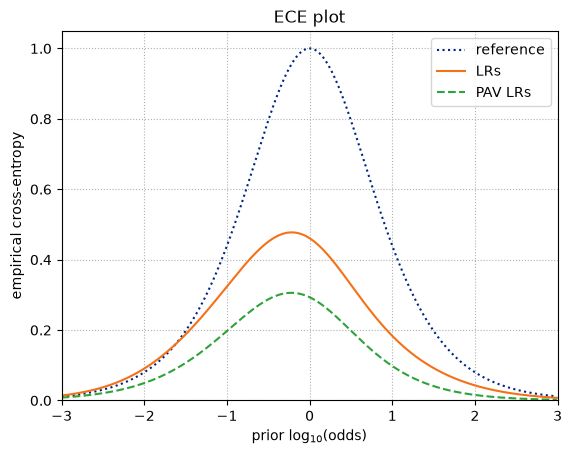

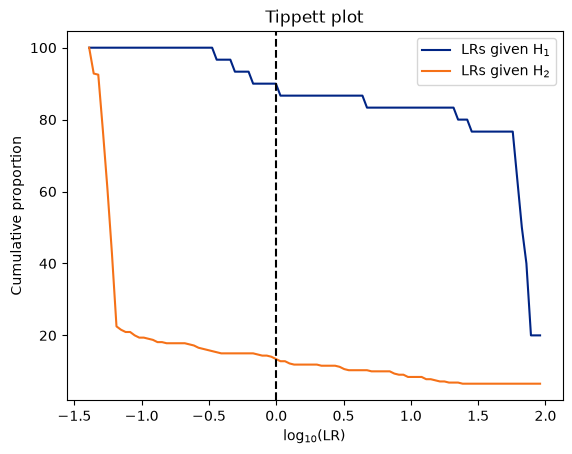

  Rates of misleading evidence:
    H1: 10.0% of same-source pairs have LR < 1 (misleading)
    H2: 13.4% of different-source pairs have LR >= 1 (misleading)


In [196]:
# === Step 7: Validate LR system (Option 1: Euclidean + KDE) ===
# Leave-one-sample-out CV: for each fold, hold out one sample entirely,
# compute Euclidean distance scores for held-out pairs, then fit KDE calibrator
# on training scores and apply to test scores. No classifier needed.

val_source_ids = np.array(wt_dist.index.get_level_values('Sample').values)
unique_samples_val = np.unique(val_source_ids)

all_cv_llrs = []
all_cv_labels = []

print("Leave-one-sample-out CV for Euclidean distance + KDE + ELUB")
print("=" * 60)

for held_out in unique_samples_val:
    # Split
    train_mask = val_source_ids != held_out
    test_mask = val_source_ids == held_out
    
    train_features = wt_dist.values[train_mask]
    train_ids = val_source_ids[train_mask]
    test_features = wt_dist.values[test_mask]
    n_test = test_features.shape[0]
    n_train = train_features.shape[0]
    
    # Compute training scores (Euclidean distances between training pairs)
    train_same_scores = []
    train_diff_scores = []
    for i in range(n_train):
        for j in range(i + 1, n_train):
            d = np.sqrt(np.sum((train_features[i] - train_features[j])**2))
            if train_ids[i] == train_ids[j]:
                train_same_scores.append(d)
            else:
                train_diff_scores.append(d)
    
    # Fit KDE + ELUB calibrator on training scores
    train_scores = np.concatenate([train_same_scores, train_diff_scores])
    train_labels = np.concatenate([
        np.ones(len(train_same_scores)),
        np.zeros(len(train_diff_scores))
    ])
    train_score_data = FeatureData(features=train_scores, labels=train_labels)
    
    calibrator_cv = LirPipeline([
        ('kde', KDECalibrator(bandwidth='silverman')),
        ('elub', ELUBBounder()),
    ])
    calibrator_cv.fit(train_score_data)
    
    # Compute test scores and apply fitted calibrator
    # Same-source: within held-out sample
    for i in range(n_test):
        for j in range(i + 1, n_test):
            d = np.sqrt(np.sum((test_features[i] - test_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([1]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(1)
    
    # Different-source: held-out vs training
    for i in range(n_test):
        for j in range(n_train):
            d = np.sqrt(np.sum((test_features[i] - train_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([0]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(0)
    
    n_same = n_test * (n_test - 1) // 2
    n_diff = n_test * n_train
    print(f"  Fold (held out: {held_out}): {n_same} same-source, {n_diff} different-source pairs")

# Combine all CV LRs
cv_llrs_euclidean = np.array(all_cv_llrs)
cv_labels_euclidean = np.array(all_cv_labels)
lrs_cv_euclidean = LLRData(features=cv_llrs_euclidean, labels=cv_labels_euclidean)

# Compute Cllr
cllr_cv_euclidean = compute_cllr(lrs_cv_euclidean)
print(f"\n{'=' * 60}")
print(f"  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)")
print(f"{'=' * 60}")
print(f"  Cllr (LOSO-CV): {cllr_cv_euclidean:.4f}")
print(f"  Total pairs: {len(cv_llrs_euclidean)} (same: {cv_labels_euclidean.sum():.0f}, diff: {(1-cv_labels_euclidean).sum():.0f})")

# Override lir default plot colors with custom palette
_lir_plotting.H1_COLOR = mycolors2[0]
_lir_plotting.H2_COLOR = mycolors2[1]

# LR histogram
with show() as ax:
    ax.lr_histogram(lrs_cv_euclidean)
    ax.title('LR Histogram')
#    ax.figure.savefig('img/LR_histogram_LR1.svg', transparent=True)

# PAV plot
with show() as ax:
    ax.pav(lrs_cv_euclidean)
    for coll in ax.ax.collections:
        coll.set_sizes([120])
        coll.set_linewidths(1.5)
    ax.title('PAV plot')
#    ax.figure.savefig('img/PAV_plot_LR1.svg', transparent=True)

# ECE plot
with show() as ax:
    ax.ece(lrs_cv_euclidean)
    ax.title('ECE plot')
#    ax.figure.savefig('img/ECE_plot_LR1.svg', transparent=True)

# Tippett plot (uses hardcoded 'b'/'r', override manually)
with show() as ax:
    llrs_t = lrs_cv_euclidean.llrs
    labels_t = lrs_cv_euclidean.require_labels
    lr_0, lr_1 = _lir_util.Xy_to_Xn(llrs_t, labels_t)
    xvalues = np.linspace(np.min(llrs_t[np.isfinite(llrs_t)]), np.max(llrs_t[np.isfinite(llrs_t)]), 100)
    perc0 = (sum(i >= xvalues for i in lr_0) / len(lr_0)) * 100
    perc1 = (sum(i >= xvalues for i in lr_1) / len(lr_1)) * 100
    ax.ax.plot(xvalues, perc1, color=mycolors2[0], label=r'LRs given $\mathregular{H_1}$')
    ax.ax.plot(xvalues, perc0, color=mycolors2[1], label=r'LRs given $\mathregular{H_2}$')
    ax.ax.axvline(x=0, color='k', linestyle='--')
    ax.ax.set_xlabel('log$_{10}$(LR)')
    ax.ax.set_ylabel('Cumulative proportion')
    ax.ax.legend()
    ax.title('Tippett plot')
#    ax.figure.savefig('img/Tippett_plot_LR1.svg', transparent=True)

# Rates of misleading evidence at log10(LR) = 0
prop_h1_at_0 = (np.sum(lr_1 >= 0) / len(lr_1)) * 100
prop_h2_at_0 = (np.sum(lr_0 >= 0) / len(lr_0)) * 100
print(f"  Rates of misleading evidence:")
print(f"    H1: {100 - prop_h1_at_0:.1f}% of same-source pairs have LR < 1 (misleading)")
print(f"    H2: {prop_h2_at_0:.1f}% of different-source pairs have LR >= 1 (misleading)")

In [197]:
# Tippett plot x-range (log10 LR values)
llrs_finite = lrs_cv_euclidean.llrs[np.isfinite(lrs_cv_euclidean.llrs)]
x_min = llrs_finite.min()
x_max = llrs_finite.max()
print(f"Tippett x-axis range:")
print(f"  min log10(LR) = {x_min:.4f}  →  LR = {10**x_min:.4f}")
print(f"  max log10(LR) = {x_max:.4f}  →  LR = {10**x_max:.4f}")

Tippett x-axis range:
  min log10(LR) = -1.3900  →  LR = 0.0407
  max log10(LR) = 1.9600  →  LR = 91.2011


Fit the selected LR system (Euclidean distance + KDE + ELUB) on all available reference data, then apply it to the casework observations to obtain LRs.

- **Observation 1**: Sample 356 (DI-U)
- **Observation 2**: Sample 876 (DI-U)

In [198]:
# === Step 8: Construct casework LR system ===
# Fit Euclidean + KDE + ELUB on ALL background reference data (wt_dist = DI-R)
# Then apply to casework observation pair (356 vs 876)

# --- 1. Fit calibrator on all pairwise Euclidean distances from background data ---
bg_samples = wt_dist.index.get_level_values('Sample').values
bg_features = wt_dist.values
n_bg = len(bg_features)

bg_same_scores = []
bg_diff_scores = []
for i in range(n_bg):
    for j in range(i + 1, n_bg):
        d = np.sqrt(np.sum((bg_features[i] - bg_features[j])**2))
        if bg_samples[i] == bg_samples[j]:
            bg_same_scores.append(d)
        else:
            bg_diff_scores.append(d)

bg_scores = np.concatenate([bg_same_scores, bg_diff_scores])
bg_labels = np.concatenate([np.ones(len(bg_same_scores)), np.zeros(len(bg_diff_scores))])
bg_score_data = FeatureData(features=bg_scores, labels=bg_labels)

# Fit the casework LR system (KDE + ELUB) on all background scores
casework_lr_system = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
casework_lr_system.fit(bg_score_data)

print("Casework LR system fitted on all DI-R background data")
print(f"  Background pairs: {len(bg_same_scores)} same-source, {len(bg_diff_scores)} different-source")

# --- 2. Prepare casework observations ---
# Align columns: use same features as background (wt_dist)
shared_cols = wt_dist.columns.intersection(widetable_DI_LR1.columns)

# Casework observations with log10 transform (matching background)
casework_data = widetable_DI_LR1[shared_cols].apply(lambda x: np.log10(x + 1))

obs1 = casework_data.xs('356', level='Sample')  # Observation 1: sample 356
obs2 = casework_data.xs('876', level='Sample')  # Observation 2: sample 876

print(f"\n  Observation 1 (sample 356): {len(obs1)} replicates")
print(f"  Observation 2 (sample 876): {len(obs2)} replicates")
print(f"  Shared features: {len(shared_cols)}")

# --- 3. Compute Euclidean distances between all pairs of replicates ---
casework_distances = []
pair_labels = []

for i, (idx1, row1) in enumerate(obs1.iterrows()):
    for j, (idx2, row2) in enumerate(obs2.iterrows()):
        d = np.sqrt(np.sum((row1.values - row2.values)**2))
        rep1 = idx1[-1] if isinstance(idx1, tuple) else idx1
        rep2 = idx2[-1] if isinstance(idx2, tuple) else idx2
        casework_distances.append(d)
        pair_labels.append(f"356_rep{rep1} vs 876_rep{rep2}")

casework_distances = np.array(casework_distances)

# --- 4. Apply the fitted LR system to get LRs ---
casework_fd = FeatureData(features=casework_distances, labels=np.ones(len(casework_distances)))
casework_llr_data = casework_lr_system.apply(casework_fd)
casework_llrs = casework_llr_data.features.flatten()  # log10(LR) values
casework_lrs = 10**casework_llrs  # Convert log10LR to LR

print(f"\n{'=' * 60}")
print(f"  CASEWORK LR RESULTS (Sample 356 vs Sample 876)")
print(f"{'=' * 60}")
print(f"  {'Pair':<30} {'Distance':>10} {'log10(LR)':>10} {'LR':>12}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*12}")
for label, dist, llr, lr in zip(pair_labels, casework_distances, casework_llrs, casework_lrs):
    print(f"  {label:<30} {dist:>10.3f} {llr:>10.3f} {lr:>12.3f}")

# Summary statistics
mean_llr = np.mean(casework_llrs)
median_llr = np.median(casework_llrs)
print(f"\n  Summary:")
print(f"  Mean log10(LR):   {mean_llr:.3f}  (LR = {10**mean_llr:.3f})")
print(f"  Median log10(LR): {median_llr:.3f}  (LR = {10**median_llr:.3f})")

Casework LR system fitted on all DI-R background data
  Background pairs: 30 same-source, 160 different-source

  Observation 1 (sample 356): 4 replicates
  Observation 2 (sample 876): 4 replicates
  Shared features: 11

  CASEWORK LR RESULTS (Sample 356 vs Sample 876)
  Pair                             Distance  log10(LR)           LR
  ------------------------------ ---------- ---------- ------------
  356_rep1 vs 876_rep1                5.264      2.050      112.202
  356_rep1 vs 876_rep2                5.115      2.050      112.202
  356_rep1 vs 876_rep3                5.287      2.050      112.202
  356_rep1 vs 876_rep4                5.333      2.050      112.202
  356_rep2 vs 876_rep1                5.772      2.050      112.202
  356_rep2 vs 876_rep2                4.273      2.050      112.202
  356_rep2 vs 876_rep3                4.385      2.050      112.202
  356_rep2 vs 876_rep4                4.385      2.050      112.202
  356_rep3 vs 876_rep1                5.389      2

LR range of this system (KDE + ELUB calibrator):
  Min log10(LR) = -1.670  →  LR = 0.0214
  Max log10(LR) = 2.360  →  LR = 229.09


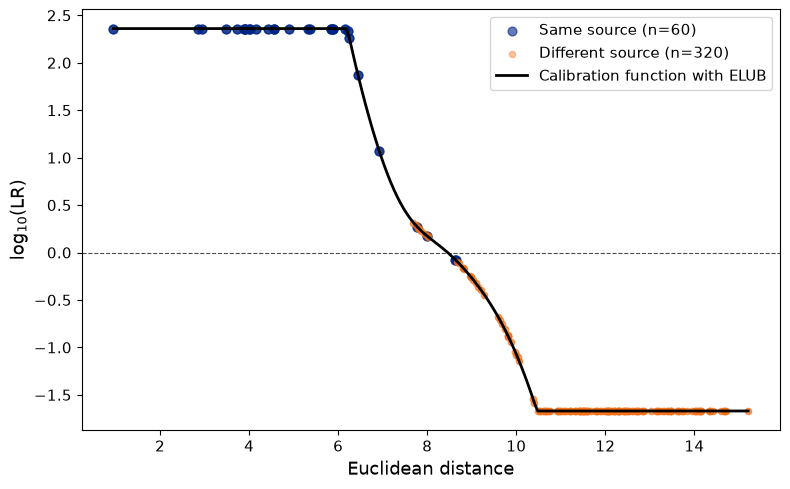

In [199]:
# Distance vs log10(LR) scatter plot using CV results
# Use the full-data calibrator (fitted on all pairs) to show the mapping curve,
# and overlay the CV distances colored by ground truth

# Fit calibrator on all pairwise distances (same as Step 5/6)
all_distances = np.concatenate([same_source, diff_source])
all_labels_dist = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
score_data_full = FeatureData(features=all_distances, labels=all_labels_dist)

cal_full = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
cal_full.fit(score_data_full)

# Get calibrated LRs for all distances
llr_all = cal_full.apply(score_data_full)

fig, ax = plt.subplots(figsize=(8, 5))

# Scatter: same-source
mask_same = all_labels_dist == 1
mask_diff = all_labels_dist == 0
ax.scatter(all_distances[mask_same], llr_all.features[mask_same],
           color=mycolors2[0], alpha=0.6, s=40, label=f'Same source (n={mask_same.sum()})')
ax.scatter(all_distances[mask_diff], llr_all.features[mask_diff],
           color=mycolors2[1], alpha=0.4, s=20, label=f'Different source (n={mask_diff.sum()})')

# Calibration curve: smooth mapping from distance → LR
d_range = np.linspace(all_distances.min(), all_distances.max(), 200)
d_fd = FeatureData(features=d_range)
llr_curve = cal_full.apply(d_fd)
ax.plot(d_range, llr_curve.features, 'k-', linewidth=2, label='Calibration function with ELUB')

# Reference line at log10(LR) = 0
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('Euclidean distance', fontsize=13)
ax.set_ylabel('log$_{10}$(LR)', fontsize=13)
#ax.set_title('Distance vs. Likelihood Ratio (KDE + ELUB calibrator)')
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)

#ax.figure.savefig('img/Distance_vs_LR1.svg', transparent=True)

plt.tight_layout()

# Report min and max LR obtainable with this system
min_llr = llr_curve.features.min()
max_llr = llr_curve.features.max()
print(f"LR range of this system (KDE + ELUB calibrator):")
print(f"  Min log10(LR) = {min_llr:.3f}  →  LR = {10**min_llr:.4f}")
print(f"  Max log10(LR) = {max_llr:.3f}  →  LR = {10**max_llr:.2f}")

##### LR2

In [200]:
# === Step 8: Construct casework LR system ===
# Fit Euclidean + KDE + ELUB on ALL background reference data (wt_dist = DI-R)
# Then apply to casework observation pair (356 vs 361)

# --- 1. Fit calibrator on all pairwise Euclidean distances from background data ---
bg_samples = wt_dist.index.get_level_values('Sample').values
bg_features = wt_dist.values
n_bg = len(bg_features)

bg_same_scores = []
bg_diff_scores = []
for i in range(n_bg):
    for j in range(i + 1, n_bg):
        d = np.sqrt(np.sum((bg_features[i] - bg_features[j])**2))
        if bg_samples[i] == bg_samples[j]:
            bg_same_scores.append(d)
        else:
            bg_diff_scores.append(d)

bg_scores = np.concatenate([bg_same_scores, bg_diff_scores])
bg_labels = np.concatenate([np.ones(len(bg_same_scores)), np.zeros(len(bg_diff_scores))])
bg_score_data = FeatureData(features=bg_scores, labels=bg_labels)

# Fit the casework LR system (KDE + ELUB) on all background scores
casework_lr_system = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
casework_lr_system.fit(bg_score_data)

print("Casework LR system fitted on all DI-R background data")
print(f"  Background pairs: {len(bg_same_scores)} same-source, {len(bg_diff_scores)} different-source")

# --- 2. Prepare casework observations ---
# Align columns: use same features as background (wt_dist)
shared_cols = wt_dist.columns.intersection(widetable_DI_LR2.columns)

# Casework observations with log10 transform (matching background)
casework_data = widetable_DI_LR2[shared_cols].apply(lambda x: np.log10(x + 1))

obs1 = casework_data.xs('356', level='Sample')  # Observation 1: sample 356
obs2 = casework_data.xs('361', level='Sample')  # Observation 2: sample 876

print(f"\n  Observation 1 (sample 356): {len(obs1)} replicates")
print(f"  Observation 2 (sample 876): {len(obs2)} replicates")
print(f"  Shared features: {len(shared_cols)}")

# --- 3. Compute Euclidean distances between all pairs of replicates ---
casework_distances = []
pair_labels = []

for i, (idx1, row1) in enumerate(obs1.iterrows()):
    for j, (idx2, row2) in enumerate(obs2.iterrows()):
        d = np.sqrt(np.sum((row1.values - row2.values)**2))
        rep1 = idx1[-1] if isinstance(idx1, tuple) else idx1
        rep2 = idx2[-1] if isinstance(idx2, tuple) else idx2
        casework_distances.append(d)
        pair_labels.append(f"356_rep{rep1} vs 876_rep{rep2}")

casework_distances = np.array(casework_distances)

# --- 4. Apply the fitted LR system to get LRs ---
casework_fd = FeatureData(features=casework_distances, labels=np.ones(len(casework_distances)))
casework_llr_data = casework_lr_system.apply(casework_fd)
casework_llrs = casework_llr_data.features.flatten()  # log10(LR) values
casework_lrs = 10**casework_llrs  # Convert log10LR to LR

print(f"\n{'=' * 60}")
print(f"  CASEWORK LR RESULTS (Sample A vs Sample B)")
print(f"{'=' * 60}")
print(f"  {'Pair':<30} {'Distance':>10} {'log10(LR)':>10} {'LR':>12}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*12}")
for label, dist, llr, lr in zip(pair_labels, casework_distances, casework_llrs, casework_lrs):
    print(f"  {label:<30} {dist:>10.3f} {llr:>10.3f} {lr:>12.3f}")

# Summary statistics
mean_llr = np.mean(casework_llrs)
median_llr = np.median(casework_llrs)
print(f"\n  Summary:")
print(f"  Mean log10(LR):   {mean_llr:.3f}  (LR = {10**mean_llr:.3f})")
print(f"  Median log10(LR): {median_llr:.3f}  (LR = {10**median_llr:.3f})")

Casework LR system fitted on all DI-R background data
  Background pairs: 30 same-source, 160 different-source

  Observation 1 (sample 356): 4 replicates
  Observation 2 (sample 876): 4 replicates
  Shared features: 10

  CASEWORK LR RESULTS (Sample A vs Sample B)
  Pair                             Distance  log10(LR)           LR
  ------------------------------ ---------- ---------- ------------
  356_rep1 vs 876_rep1                9.789     -0.781        0.166
  356_rep1 vs 876_rep2                9.872     -0.850        0.141
  356_rep1 vs 876_rep3                9.870     -0.849        0.142
  356_rep1 vs 876_rep4                9.897     -0.871        0.134
  356_rep2 vs 876_rep1                9.046     -0.297        0.505
  356_rep2 vs 876_rep2                9.065     -0.306        0.494
  356_rep2 vs 876_rep3                9.102     -0.326        0.472
  356_rep2 vs 876_rep4                9.075     -0.312        0.488
  356_rep3 vs 876_rep1                9.033     -0.290

#### Dataset 2

##### LR3

Cross-validated scores (leave-one-sample-out):
  Same-source pairs: 60
  Different-source pairs: 320

Cllr (KDE calibrator): 0.142


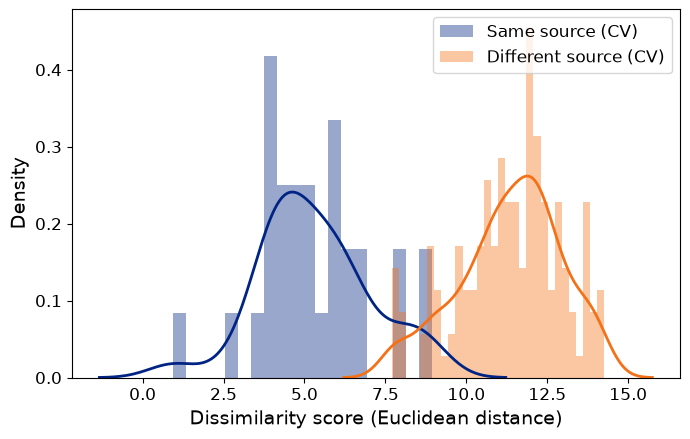

In [201]:
# Compute pairwise dissimilarity scores (Euclidean) with cross-validation
# Using leave-one-sample-out CV to avoid information leakage

# Aggregate: max area per compound for each Sample-Replicate
wt_dist = (widetable_DI_LR3_ref
    .reset_index()
    .groupby(['Category', 'Type', 'Sample', 'Replicate'])
    .max()
)
wt_dist = wt_dist.apply(lambda x: np.log10(x + 1))

samples_dist = wt_dist.index.get_level_values('Sample').values
unique_samples = np.unique(samples_dist)

# Leave-one-sample-out CV: for each fold, hold out one sample
# Compute scores for held-out pairs using distributions from training pairs
all_same_scores = []
all_diff_scores = []
cv_same_scores = []
cv_diff_scores = []

for held_out in unique_samples:
    # Split into train and test
    test_mask = samples_dist == held_out
    train_mask = ~test_mask
    
    train_data = wt_dist[train_mask]
    test_data = wt_dist[test_mask]
    train_samples = samples_dist[train_mask]
    
    # Compute distances between test replicates and all training replicates
    for i, (idx_test, row_test) in enumerate(test_data.iterrows()):
        # Same-source: distance between test replicate and other replicates of same sample
        other_test = test_data.drop(index=idx_test)
        for idx_other, row_other in other_test.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_other.values)**2))
            cv_same_scores.append(d)
        
        # Different-source: distance between test replicate and training replicates
        for idx_train, row_train in train_data.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_train.values)**2))
            cv_diff_scores.append(d)

# Also compute full pairwise distances for comparison
dist_vec = pdist(wt_dist, metric='euclidean')
dist_mat = squareform(dist_vec)

n = len(samples_dist)
for i in range(n):
    for j in range(i + 1, n):
        d = dist_mat[i, j]
        if samples_dist[i] == samples_dist[j]:
            all_same_scores.append(d)
        else:
            all_diff_scores.append(d)

same_source = np.array(cv_same_scores)
diff_source = np.array(cv_diff_scores)

print(f"Cross-validated scores (leave-one-sample-out):")
print(f"  Same-source pairs: {len(same_source)}")
print(f"  Different-source pairs: {len(diff_source)}")

# Plot histogram + KDE
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(same_source, bins=20, density=True, alpha=0.4, color='#002484', label='Same source (CV)')
ax.hist(diff_source, bins=30, density=True, alpha=0.4, color='#f57118', label='Different source (CV)')

sns.kdeplot(same_source, ax=ax, color='#002484', linewidth=2)
sns.kdeplot(diff_source, ax=ax, color='#f57118', linewidth=2)

ax.set_xlabel('Dissimilarity score (Euclidean distance)', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
plt.tight_layout()

# Compute calibrated LRs using lir KDECalibrator (lir 1.6.0 API)
scores = np.concatenate([same_source, diff_source])
y_true = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])

# Create FeatureData with scores and labels
score_data = FeatureData(features=scores, labels=y_true)

# Fit KDE-based calibrator
cal = KDECalibrator(bandwidth='silverman')
cal.fit(score_data)

# Apply calibrator to get LLRs
llr_data = LLRData(**cal.apply(score_data).model_dump())

# Compute Cllr
cllr_value = compute_cllr(llr_data)
print(f"\nCllr (KDE calibrator): {cllr_value:.3f}")

#plt.savefig('img/dissimilarity_GCMS_hist_kde_CV_LR3.svg', transparent=True)

In [202]:
# === Step 6: Compare LR systems ===
# Using the CV dissimilarity scores computed above (same_source, diff_source)
# and SVM-based scores on DI-R paired data

# --- Prepare Euclidean distance score data ---
euclidean_scores = np.concatenate([same_source, diff_source])
euclidean_labels = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
euclidean_score_data = FeatureData(features=euclidean_scores, labels=euclidean_labels)

# --- Prepare SVM scores on DI-R pairs ---
# Create paired data from widetable_DI_R
wt_svm_lr = wt_dist.copy()
svm_source_ids = np.array(wt_svm_lr.index.get_level_values('Sample').values)

svm_features = wt_svm_lr.values
svm_fd = FeatureData(features=svm_features, source_ids=svm_source_ids)

instance_pairer = InstancePairing(ratio_limit=2)
svm_pairs = instance_pairer.pair(svm_fd)

# SVM pipeline: abs difference -> SVC -> probability to log odds
svm_scorer = LirPipeline([
    ('abs_difference', ElementWiseDifference()),
    ('classifier', SVC(probability=True)),
])
svm_scorer.fit(svm_pairs)
svm_score_data = svm_scorer.apply(svm_pairs)

print("=" * 60)
print("LR SYSTEM COMPARISON (Step 6)")
print("=" * 60)

# --- Define 4 LR systems ---
systems = {
    "Option 1: Euclidean + KDE": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 2: Euclidean + Logistic Regression": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
    "Option 3: SVM + KDE": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 4: SVM + Logistic Regression": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
}

# --- Evaluate each system ---
for name, system in systems.items():
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    
    sd = system["score_data"]
    calibrator = system["calibrator"]
    
    # Fit and apply calibrator
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    
    # Compute Cllr
    cllr_val = compute_cllr(lrs)
    print(f"  Cllr: {cllr_val:.4f}")
    
    # # LR histogram
    # with show() as ax:
    #     ax.lr_histogram(lrs)
    #     ax.title(f'{name} - LR Histogram')
    
    # # PAV plot
    # with show() as ax:
    #     ax.pav(lrs)
    #     ax.title(f'{name} - PAV plot')

print(f"\n{'=' * 60}")
print("SUMMARY")
print(f"{'=' * 60}")
for name, system in systems.items():
    sd = system["score_data"]
    calibrator = system["calibrator"]
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    cllr_val = compute_cllr(lrs)
    print(f"  {name:<45} Cllr = {cllr_val:.4f}")

LR SYSTEM COMPARISON (Step 6)

──────────────────────────────────────────────────
  Option 1: Euclidean + KDE
──────────────────────────────────────────────────
  Cllr: 0.1554

──────────────────────────────────────────────────
  Option 2: Euclidean + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1632

──────────────────────────────────────────────────
  Option 3: SVM + KDE
──────────────────────────────────────────────────
  Cllr: 0.0356

──────────────────────────────────────────────────
  Option 4: SVM + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1571

SUMMARY
  Option 1: Euclidean + KDE                     Cllr = 0.1554
  Option 2: Euclidean + Logistic Regression     Cllr = 0.1632
  Option 3: SVM + KDE                           Cllr = 0.0356
  Option 4: SVM + Logistic Regression           Cllr = 0.1571


c:\Scripts\Icarus\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Leave-one-sample-out CV for Euclidean distance + KDE + ELUB
  Fold (held out: 067): 6 same-source, 64 different-source pairs
  Fold (held out: 184): 6 same-source, 64 different-source pairs
  Fold (held out: 433): 6 same-source, 64 different-source pairs
  Fold (held out: 876): 6 same-source, 64 different-source pairs
  Fold (held out: 893): 6 same-source, 64 different-source pairs

  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)
  Cllr (LOSO-CV): 0.5014
  Total pairs: 350 (same: 30, diff: 320)


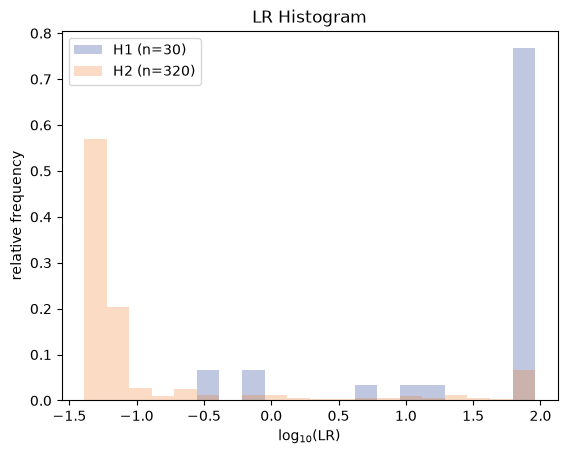

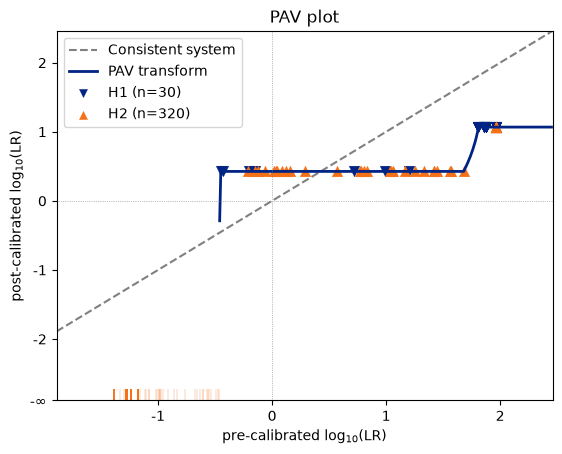

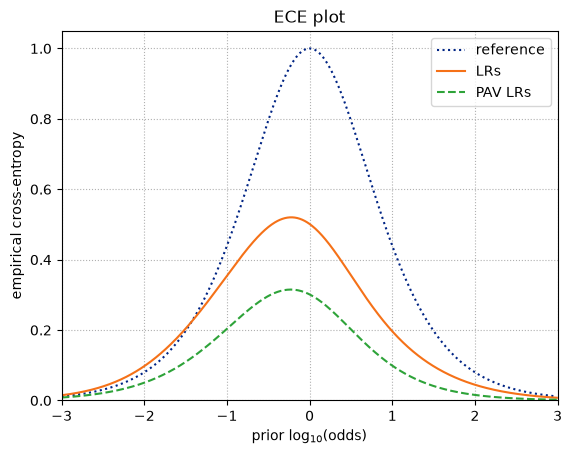

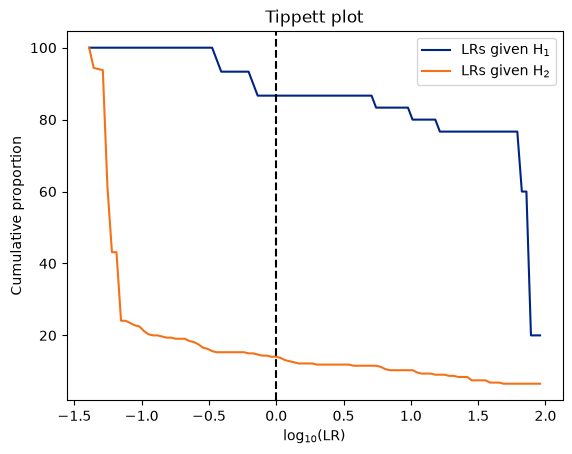

  Rates of misleading evidence:
    H1: 13.3% of same-source pairs have LR < 1 (misleading)
    H2: 14.1% of different-source pairs have LR >= 1 (misleading)


In [203]:
# === Step 7: Validate LR system (Option 1: Euclidean + KDE) ===
# Leave-one-sample-out CV: for each fold, hold out one sample entirely,
# compute Euclidean distance scores for held-out pairs, then fit KDE calibrator
# on training scores and apply to test scores. No classifier needed.

val_source_ids = np.array(wt_dist.index.get_level_values('Sample').values)
unique_samples_val = np.unique(val_source_ids)

all_cv_llrs = []
all_cv_labels = []

print("Leave-one-sample-out CV for Euclidean distance + KDE + ELUB")
print("=" * 60)

for held_out in unique_samples_val:
    # Split
    train_mask = val_source_ids != held_out
    test_mask = val_source_ids == held_out
    
    train_features = wt_dist.values[train_mask]
    train_ids = val_source_ids[train_mask]
    test_features = wt_dist.values[test_mask]
    n_test = test_features.shape[0]
    n_train = train_features.shape[0]
    
    # Compute training scores (Euclidean distances between training pairs)
    train_same_scores = []
    train_diff_scores = []
    for i in range(n_train):
        for j in range(i + 1, n_train):
            d = np.sqrt(np.sum((train_features[i] - train_features[j])**2))
            if train_ids[i] == train_ids[j]:
                train_same_scores.append(d)
            else:
                train_diff_scores.append(d)
    
    # Fit KDE + ELUB calibrator on training scores
    train_scores = np.concatenate([train_same_scores, train_diff_scores])
    train_labels = np.concatenate([
        np.ones(len(train_same_scores)),
        np.zeros(len(train_diff_scores))
    ])
    train_score_data = FeatureData(features=train_scores, labels=train_labels)
    
    calibrator_cv = LirPipeline([
        ('kde', KDECalibrator(bandwidth='silverman')),
        ('elub', ELUBBounder()),
    ])
    calibrator_cv.fit(train_score_data)
    
    # Compute test scores and apply fitted calibrator
    # Same-source: within held-out sample
    for i in range(n_test):
        for j in range(i + 1, n_test):
            d = np.sqrt(np.sum((test_features[i] - test_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([1]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(1)
    
    # Different-source: held-out vs training
    for i in range(n_test):
        for j in range(n_train):
            d = np.sqrt(np.sum((test_features[i] - train_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([0]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(0)
    
    n_same = n_test * (n_test - 1) // 2
    n_diff = n_test * n_train
    print(f"  Fold (held out: {held_out}): {n_same} same-source, {n_diff} different-source pairs")

# Combine all CV LRs
cv_llrs_euclidean = np.array(all_cv_llrs)
cv_labels_euclidean = np.array(all_cv_labels)
lrs_cv_euclidean = LLRData(features=cv_llrs_euclidean, labels=cv_labels_euclidean)

# Compute Cllr
cllr_cv_euclidean = compute_cllr(lrs_cv_euclidean)
print(f"\n{'=' * 60}")
print(f"  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)")
print(f"{'=' * 60}")
print(f"  Cllr (LOSO-CV): {cllr_cv_euclidean:.4f}")
print(f"  Total pairs: {len(cv_llrs_euclidean)} (same: {cv_labels_euclidean.sum():.0f}, diff: {(1-cv_labels_euclidean).sum():.0f})")

# Override lir default plot colors with custom palette
_lir_plotting.H1_COLOR = mycolors2[0]
_lir_plotting.H2_COLOR = mycolors2[1]

# LR histogram
with show() as ax:
    ax.lr_histogram(lrs_cv_euclidean)
    ax.title('LR Histogram')
#    ax.figure.savefig('img/LR_histogram_LR3.svg', transparent=True)

# PAV plot
with show() as ax:
    ax.pav(lrs_cv_euclidean)
    for coll in ax.ax.collections:
        coll.set_sizes([60])
    ax.title('PAV plot')
#    ax.figure.savefig('img/PAV_plot_LR3.svg', transparent=True)

# ECE plot
with show() as ax:
    ax.ece(lrs_cv_euclidean)
    ax.title('ECE plot')
#    ax.figure.savefig('img/ECE_plot_LR3.svg', transparent=True)

# Tippett plot (uses hardcoded 'b'/'r', override manually)
with show() as ax:
    llrs_t = lrs_cv_euclidean.llrs
    labels_t = lrs_cv_euclidean.require_labels
    lr_0, lr_1 = _lir_util.Xy_to_Xn(llrs_t, labels_t)
    xvalues = np.linspace(np.min(llrs_t[np.isfinite(llrs_t)]), np.max(llrs_t[np.isfinite(llrs_t)]), 100)
    perc0 = (sum(i >= xvalues for i in lr_0) / len(lr_0)) * 100
    perc1 = (sum(i >= xvalues for i in lr_1) / len(lr_1)) * 100
    ax.ax.plot(xvalues, perc1, color=mycolors2[0], label=r'LRs given $\mathregular{H_1}$')
    ax.ax.plot(xvalues, perc0, color=mycolors2[1], label=r'LRs given $\mathregular{H_2}$')
    ax.ax.axvline(x=0, color='k', linestyle='--')
    ax.ax.set_xlabel('log$_{10}$(LR)')
    ax.ax.set_ylabel('Cumulative proportion')    
    ax.ax.legend()        
    ax.title('Tippett plot')
#    ax.figure.savefig('img/Tippett_plot_LR3.svg', transparent=True)

# Rates of misleading evidence at log10(LR) = 0
prop_h1_at_0 = (np.sum(lr_1 >= 0) / len(lr_1)) * 100
prop_h2_at_0 = (np.sum(lr_0 >= 0) / len(lr_0)) * 100
print(f"  Rates of misleading evidence:")
print(f"    H1: {100 - prop_h1_at_0:.1f}% of same-source pairs have LR < 1 (misleading)")
print(f"    H2: {prop_h2_at_0:.1f}% of different-source pairs have LR >= 1 (misleading)")

In [204]:
# Tippett plot x-range (log10 LR values)
llrs_finite = lrs_cv_euclidean.llrs[np.isfinite(lrs_cv_euclidean.llrs)]
x_min = llrs_finite.min()
x_max = llrs_finite.max()
print(f"Tippett x-axis range:")
print(f"  min log10(LR) = {x_min:.4f}  →  LR = {10**x_min:.4f}")
print(f"  max log10(LR) = {x_max:.4f}  →  LR = {10**x_max:.4f}")

Tippett x-axis range:
  min log10(LR) = -1.3900  →  LR = 0.0407
  max log10(LR) = 1.9600  →  LR = 91.2011


Fit the selected LR system (Euclidean distance + KDE + ELUB) on all available reference data, then apply it to the casework observations to obtain LRs.

- **Observation 1**: 
- **Observation 2**: 

In [205]:
# === Step 8: Construct casework LR system ===
# Fit Euclidean + KDE + ELUB on ALL background reference data (wt_dist = DI-R)
# Then apply to casework observation pair (x)

# --- 1. Fit calibrator on all pairwise Euclidean distances from background data ---
bg_samples = wt_dist.index.get_level_values('Sample').values
bg_features = wt_dist.values
n_bg = len(bg_features)

bg_same_scores = []
bg_diff_scores = []
for i in range(n_bg):
    for j in range(i + 1, n_bg):
        d = np.sqrt(np.sum((bg_features[i] - bg_features[j])**2))
        if bg_samples[i] == bg_samples[j]:
            bg_same_scores.append(d)
        else:
            bg_diff_scores.append(d)

bg_scores = np.concatenate([bg_same_scores, bg_diff_scores])
bg_labels = np.concatenate([np.ones(len(bg_same_scores)), np.zeros(len(bg_diff_scores))])
bg_score_data = FeatureData(features=bg_scores, labels=bg_labels)

# Fit the casework LR system (KDE + ELUB) on all background scores
casework_lr_system = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
casework_lr_system.fit(bg_score_data)

print("Casework LR system fitted on all DI-R background data")
print(f"  Background pairs: {len(bg_same_scores)} same-source, {len(bg_diff_scores)} different-source")

# --- 2. Prepare casework observations ---
# Align columns: use same features as background (wt_dist)
shared_cols = wt_dist.columns.intersection(widetable_DI_LR3.columns)

# Casework observations with log10 transform (matching background)
casework_data = widetable_DI_LR3[shared_cols].apply(lambda x: np.log10(x + 1))

obs1 = casework_data.xs('064', level='Sample')  # Observation 1: sample 064
obs2 = casework_data.xs('561', level='Sample')  # Observation 2: sample 561

print(f"\n  Observation 1 (sample 064): {len(obs1)} replicates")
print(f"  Observation 2 (sample 561): {len(obs2)} replicates")
print(f"  Shared features: {len(shared_cols)}")

# --- 3. Compute Euclidean distances between all pairs of replicates ---
casework_distances = []
pair_labels = []

for i, (idx1, row1) in enumerate(obs1.iterrows()):
    for j, (idx2, row2) in enumerate(obs2.iterrows()):
        d = np.sqrt(np.sum((row1.values - row2.values)**2))
        rep1 = idx1[-1] if isinstance(idx1, tuple) else idx1
        rep2 = idx2[-1] if isinstance(idx2, tuple) else idx2
        casework_distances.append(d)
        pair_labels.append(f"356_rep{rep1} vs 876_rep{rep2}")

casework_distances = np.array(casework_distances)

# --- 4. Apply the fitted LR system to get LRs ---
casework_fd = FeatureData(features=casework_distances, labels=np.ones(len(casework_distances)))
casework_llr_data = casework_lr_system.apply(casework_fd)
casework_llrs = casework_llr_data.features.flatten()  # log10(LR) values
casework_lrs = 10**casework_llrs  # Convert log10LR to LR

print(f"\n{'=' * 60}")
print(f"  CASEWORK LR RESULTS (Sample 356 vs Sample 876)")
print(f"{'=' * 60}")
print(f"  {'Pair':<30} {'Distance':>10} {'log10(LR)':>10} {'LR':>12}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*12}")
for label, dist, llr, lr in zip(pair_labels, casework_distances, casework_llrs, casework_lrs):
    print(f"  {label:<30} {dist:>10.3f} {llr:>10.3f} {lr:>12.3f}")

# Summary statistics
mean_llr = np.mean(casework_llrs)
median_llr = np.median(casework_llrs)
print(f"\n  Summary:")
print(f"  Mean log10(LR):   {mean_llr:.3f}  (LR = {10**mean_llr:.3f})")
print(f"  Median log10(LR): {median_llr:.3f}  (LR = {10**median_llr:.3f})")

Casework LR system fitted on all DI-R background data
  Background pairs: 30 same-source, 160 different-source

  Observation 1 (sample 064): 4 replicates
  Observation 2 (sample 561): 4 replicates
  Shared features: 12

  CASEWORK LR RESULTS (Sample 356 vs Sample 876)
  Pair                             Distance  log10(LR)           LR
  ------------------------------ ---------- ---------- ------------
  356_rep1 vs 876_rep1                6.427      1.861       72.623
  356_rep1 vs 876_rep2                7.093      0.838        6.885
  356_rep1 vs 876_rep3                8.192      0.102        1.263
  356_rep1 vs 876_rep4                7.087      0.845        6.997
  356_rep2 vs 876_rep1                4.701      2.070      117.490
  356_rep2 vs 876_rep2                2.177      2.070      117.490
  356_rep2 vs 876_rep3                1.190      2.070      117.490
  356_rep2 vs 876_rep4                3.392      2.070      117.490
  356_rep3 vs 876_rep1                3.282      2

LR range of this system (KDE + ELUB calibrator):
  Min log10(LR) = -1.650  →  LR = 0.0224
  Max log10(LR) = 2.380  →  LR = 239.88


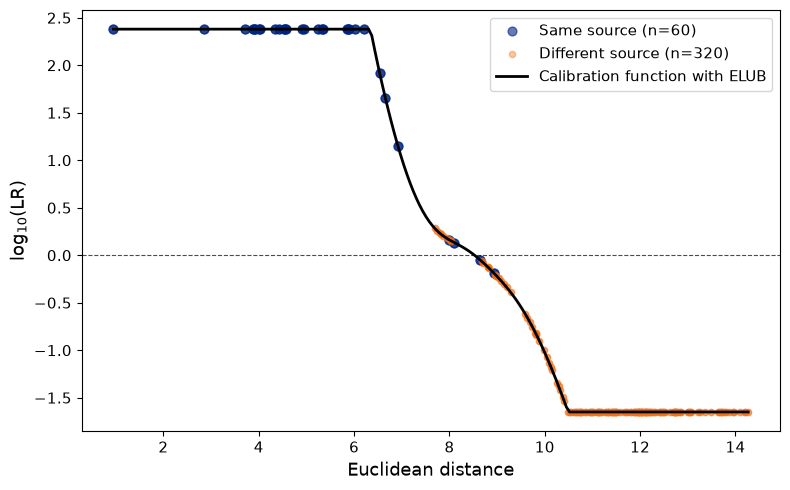

In [206]:
# Distance vs log10(LR) scatter plot using CV results
# Use the full-data calibrator (fitted on all pairs) to show the mapping curve,
# and overlay the CV distances colored by ground truth

# Fit calibrator on all pairwise distances (same as Step 5/6)
all_distances = np.concatenate([same_source, diff_source])
all_labels_dist = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
score_data_full = FeatureData(features=all_distances, labels=all_labels_dist)

cal_full = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
cal_full.fit(score_data_full)

# Get calibrated LRs for all distances
llr_all = cal_full.apply(score_data_full)

fig, ax = plt.subplots(figsize=(8, 5))

# Scatter: same-source
mask_same = all_labels_dist == 1
mask_diff = all_labels_dist == 0
ax.scatter(all_distances[mask_same], llr_all.features[mask_same],
           color=mycolors2[0], alpha=0.6, s=40, label=f'Same source (n={mask_same.sum()})')
ax.scatter(all_distances[mask_diff], llr_all.features[mask_diff],
           color=mycolors2[1], alpha=0.4, s=20, label=f'Different source (n={mask_diff.sum()})')

# Calibration curve: smooth mapping from distance → LR
d_range = np.linspace(all_distances.min(), all_distances.max(), 200)
d_fd = FeatureData(features=d_range)
llr_curve = cal_full.apply(d_fd)
ax.plot(d_range, llr_curve.features, 'k-', linewidth=2, label='Calibration function with ELUB')

# Reference line at log10(LR) = 0
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('Euclidean distance', fontsize=13)
ax.set_ylabel('log$_{10}$(LR)', fontsize=13)
#ax.set_title('Distance vs. Likelihood Ratio (KDE + ELUB calibrator)')
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)

#ax.figure.savefig('img/Distance_vs_LR1.svg', transparent=True)

plt.tight_layout()

# Report min and max LR obtainable with this system
min_llr = llr_curve.features.min()
max_llr = llr_curve.features.max()
print(f"LR range of this system (KDE + ELUB calibrator):")
print(f"  Min log10(LR) = {min_llr:.3f}  →  LR = {10**min_llr:.4f}")
print(f"  Max log10(LR) = {max_llr:.3f}  →  LR = {10**max_llr:.2f}")

#### Dataset 3

##### LR4

Cross-validated scores (leave-one-sample-out):
  Same-source pairs: 60
  Different-source pairs: 320

Cllr (KDE calibrator): 0.049


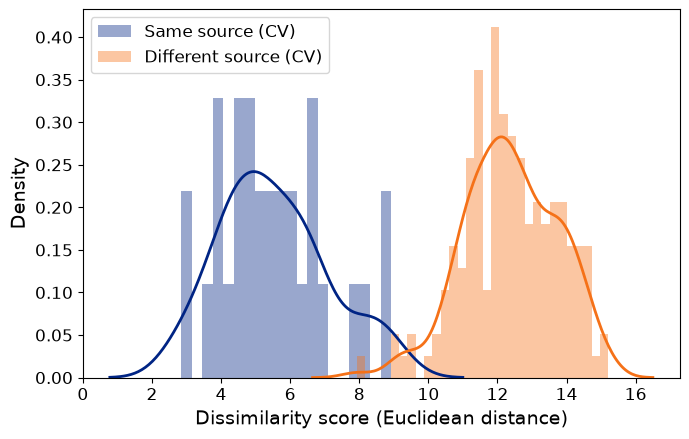

In [207]:
# Compute pairwise dissimilarity scores (Euclidean) with cross-validation
# Using leave-one-sample-out CV to avoid information leakage

# Aggregate: max area per compound for each Sample-Replicate
wt_dist = (widetable_DI_LR4_ref
    .reset_index()
    .groupby(['Category', 'Type', 'Sample', 'Replicate'])
    .max()
)
wt_dist = wt_dist.apply(lambda x: np.log10(x + 1))

samples_dist = wt_dist.index.get_level_values('Sample').values
unique_samples = np.unique(samples_dist)

# Leave-one-sample-out CV: for each fold, hold out one sample
# Compute scores for held-out pairs using distributions from training pairs
all_same_scores = []
all_diff_scores = []
cv_same_scores = []
cv_diff_scores = []

for held_out in unique_samples:
    # Split into train and test
    test_mask = samples_dist == held_out
    train_mask = ~test_mask
    
    train_data = wt_dist[train_mask]
    test_data = wt_dist[test_mask]
    train_samples = samples_dist[train_mask]
    
    # Compute distances between test replicates and all training replicates
    for i, (idx_test, row_test) in enumerate(test_data.iterrows()):
        # Same-source: distance between test replicate and other replicates of same sample
        other_test = test_data.drop(index=idx_test)
        for idx_other, row_other in other_test.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_other.values)**2))
            cv_same_scores.append(d)
        
        # Different-source: distance between test replicate and training replicates
        for idx_train, row_train in train_data.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_train.values)**2))
            cv_diff_scores.append(d)

# Also compute full pairwise distances for comparison
dist_vec = pdist(wt_dist, metric='euclidean')
dist_mat = squareform(dist_vec)

n = len(samples_dist)
for i in range(n):
    for j in range(i + 1, n):
        d = dist_mat[i, j]
        if samples_dist[i] == samples_dist[j]:
            all_same_scores.append(d)
        else:
            all_diff_scores.append(d)

same_source = np.array(cv_same_scores)
diff_source = np.array(cv_diff_scores)

print(f"Cross-validated scores (leave-one-sample-out):")
print(f"  Same-source pairs: {len(same_source)}")
print(f"  Different-source pairs: {len(diff_source)}")

# Plot histogram + KDE
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(same_source, bins=20, density=True, alpha=0.4, color='#002484', label='Same source (CV)')
ax.hist(diff_source, bins=30, density=True, alpha=0.4, color='#f57118', label='Different source (CV)')

sns.kdeplot(same_source, ax=ax, color='#002484', linewidth=2)
sns.kdeplot(diff_source, ax=ax, color='#f57118', linewidth=2)

ax.set_xlabel('Dissimilarity score (Euclidean distance)', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
plt.tight_layout()

# Compute calibrated LRs using lir KDECalibrator (lir 1.6.0 API)
scores = np.concatenate([same_source, diff_source])
y_true = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])

# Create FeatureData with scores and labels
score_data = FeatureData(features=scores, labels=y_true)

# Fit KDE-based calibrator
cal = KDECalibrator(bandwidth='silverman')
cal.fit(score_data)

# Apply calibrator to get LLRs
llr_data = LLRData(**cal.apply(score_data).model_dump())

# Compute Cllr
cllr_value = compute_cllr(llr_data)
print(f"\nCllr (KDE calibrator): {cllr_value:.3f}")

#plt.savefig('img/dissimilarity_GCMS_hist_kde_CV_LR4.svg', transparent=True)

In [208]:
# === Step 6: Compare LR systems ===
# Using the CV dissimilarity scores computed above (same_source, diff_source)
# and SVM-based scores on DI-R paired data

# --- Prepare Euclidean distance score data ---
euclidean_scores = np.concatenate([same_source, diff_source])
euclidean_labels = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
euclidean_score_data = FeatureData(features=euclidean_scores, labels=euclidean_labels)

# --- Prepare SVM scores on DI-R pairs ---
# Create paired data from widetable_DI_R
wt_svm_lr = wt_dist.copy()
svm_source_ids = np.array(wt_svm_lr.index.get_level_values('Sample').values)

svm_features = wt_svm_lr.values
svm_fd = FeatureData(features=svm_features, source_ids=svm_source_ids)

instance_pairer = InstancePairing(ratio_limit=2)
svm_pairs = instance_pairer.pair(svm_fd)

# SVM pipeline: abs difference -> SVC -> probability to log odds
svm_scorer = LirPipeline([
    ('abs_difference', ElementWiseDifference()),
    ('classifier', SVC(probability=True)),
])
svm_scorer.fit(svm_pairs)
svm_score_data = svm_scorer.apply(svm_pairs)

print("=" * 60)
print("LR SYSTEM COMPARISON (Step 6)")
print("=" * 60)

# --- Define 4 LR systems ---
systems = {
    "Option 1: Euclidean + KDE": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 2: Euclidean + Logistic Regression": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
    "Option 3: SVM + KDE": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 4: SVM + Logistic Regression": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
}

# --- Evaluate each system ---
for name, system in systems.items():
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    
    sd = system["score_data"]
    calibrator = system["calibrator"]
    
    # Fit and apply calibrator
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    
    # Compute Cllr
    cllr_val = compute_cllr(lrs)
    print(f"  Cllr: {cllr_val:.4f}")
    
    # # LR histogram
    # with show() as ax:
    #     ax.lr_histogram(lrs)
    #     ax.title(f'{name} - LR Histogram')
    
    # # PAV plot
    # with show() as ax:
    #     ax.pav(lrs)
    #     ax.title(f'{name} - PAV plot')

print(f"\n{'=' * 60}")
print("SUMMARY")
print(f"{'=' * 60}")
for name, system in systems.items():
    sd = system["score_data"]
    calibrator = system["calibrator"]
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    cllr_val = compute_cllr(lrs)
    print(f"  {name:<45} Cllr = {cllr_val:.4f}")

LR SYSTEM COMPARISON (Step 6)

──────────────────────────────────────────────────
  Option 1: Euclidean + KDE
──────────────────────────────────────────────────
  Cllr: 0.0622

──────────────────────────────────────────────────
  Option 2: Euclidean + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.0627

──────────────────────────────────────────────────
  Option 3: SVM + KDE
──────────────────────────────────────────────────
  Cllr: 0.0356

──────────────────────────────────────────────────
  Option 4: SVM + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1587

SUMMARY
  Option 1: Euclidean + KDE                     Cllr = 0.0622
  Option 2: Euclidean + Logistic Regression     Cllr = 0.0627
  Option 3: SVM + KDE                           Cllr = 0.0356
  Option 4: SVM + Logistic Regression           Cllr = 0.1587


c:\Scripts\Icarus\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Leave-one-sample-out CV for Euclidean distance + KDE + ELUB
  Fold (held out: 067): 6 same-source, 64 different-source pairs
  Fold (held out: 184): 6 same-source, 64 different-source pairs
  Fold (held out: 561): 6 same-source, 64 different-source pairs
  Fold (held out: 876): 6 same-source, 64 different-source pairs
  Fold (held out: 893): 6 same-source, 64 different-source pairs

  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)
  Cllr (LOSO-CV): 0.1975
  Total pairs: 350 (same: 30, diff: 320)


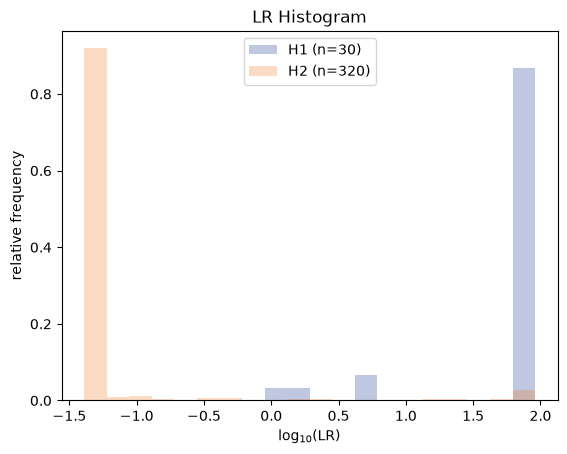

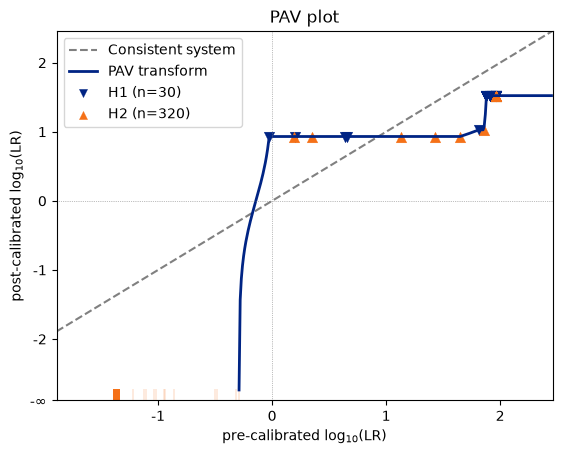

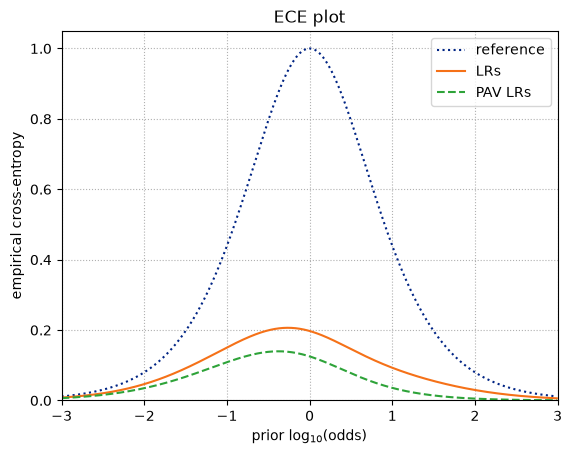

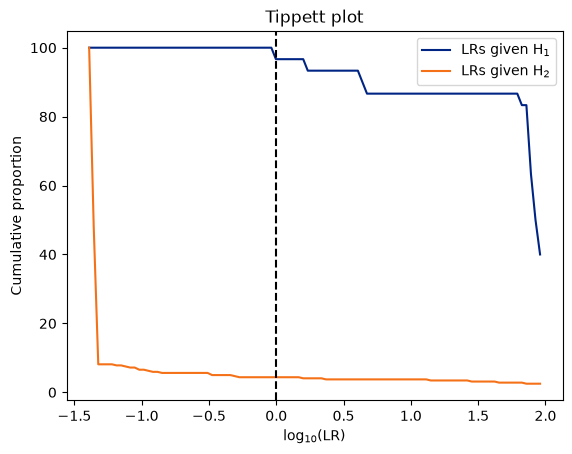

  Rates of misleading evidence:
    H1: 3.3% of same-source pairs have LR < 1 (misleading)
    H2: 4.4% of different-source pairs have LR >= 1 (misleading)


In [209]:
# === Step 7: Validate LR system (Option 1: Euclidean + KDE) ===
# Leave-one-sample-out CV: for each fold, hold out one sample entirely,
# compute Euclidean distance scores for held-out pairs, then fit KDE calibrator
# on training scores and apply to test scores. No classifier needed.

val_source_ids = np.array(wt_dist.index.get_level_values('Sample').values)
unique_samples_val = np.unique(val_source_ids)

all_cv_llrs = []
all_cv_labels = []

print("Leave-one-sample-out CV for Euclidean distance + KDE + ELUB")
print("=" * 60)

for held_out in unique_samples_val:
    # Split
    train_mask = val_source_ids != held_out
    test_mask = val_source_ids == held_out
    
    train_features = wt_dist.values[train_mask]
    train_ids = val_source_ids[train_mask]
    test_features = wt_dist.values[test_mask]
    n_test = test_features.shape[0]
    n_train = train_features.shape[0]
    
    # Compute training scores (Euclidean distances between training pairs)
    train_same_scores = []
    train_diff_scores = []
    for i in range(n_train):
        for j in range(i + 1, n_train):
            d = np.sqrt(np.sum((train_features[i] - train_features[j])**2))
            if train_ids[i] == train_ids[j]:
                train_same_scores.append(d)
            else:
                train_diff_scores.append(d)
    
    # Fit KDE + ELUB calibrator on training scores
    train_scores = np.concatenate([train_same_scores, train_diff_scores])
    train_labels = np.concatenate([
        np.ones(len(train_same_scores)),
        np.zeros(len(train_diff_scores))
    ])
    train_score_data = FeatureData(features=train_scores, labels=train_labels)
    
    calibrator_cv = LirPipeline([
        ('kde', KDECalibrator(bandwidth='silverman')),
        ('elub', ELUBBounder()),
    ])
    calibrator_cv.fit(train_score_data)
    
    # Compute test scores and apply fitted calibrator
    # Same-source: within held-out sample
    for i in range(n_test):
        for j in range(i + 1, n_test):
            d = np.sqrt(np.sum((test_features[i] - test_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([1]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(1)
    
    # Different-source: held-out vs training
    for i in range(n_test):
        for j in range(n_train):
            d = np.sqrt(np.sum((test_features[i] - train_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([0]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(0)
    
    n_same = n_test * (n_test - 1) // 2
    n_diff = n_test * n_train
    print(f"  Fold (held out: {held_out}): {n_same} same-source, {n_diff} different-source pairs")

# Combine all CV LRs
cv_llrs_euclidean = np.array(all_cv_llrs)
cv_labels_euclidean = np.array(all_cv_labels)
lrs_cv_euclidean = LLRData(features=cv_llrs_euclidean, labels=cv_labels_euclidean)

# Compute Cllr
cllr_cv_euclidean = compute_cllr(lrs_cv_euclidean)
print(f"\n{'=' * 60}")
print(f"  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)")
print(f"{'=' * 60}")
print(f"  Cllr (LOSO-CV): {cllr_cv_euclidean:.4f}")
print(f"  Total pairs: {len(cv_llrs_euclidean)} (same: {cv_labels_euclidean.sum():.0f}, diff: {(1-cv_labels_euclidean).sum():.0f})")

# Override lir default plot colors with custom palette
_lir_plotting.H1_COLOR = mycolors2[0]
_lir_plotting.H2_COLOR = mycolors2[1]

# LR histogram
with show() as ax:
    ax.lr_histogram(lrs_cv_euclidean)
    ax.title('LR Histogram')
#    ax.figure.savefig('img/LR_histogram_LR4.svg', transparent=True)

# PAV plot
with show() as ax:
    ax.pav(lrs_cv_euclidean)
    for coll in ax.ax.collections:
        coll.set_sizes([60])
    ax.title('PAV plot')
#    ax.figure.savefig('img/PAV_plot_LR4.svg', transparent=True)

# ECE plot
with show() as ax:
    ax.ece(lrs_cv_euclidean)
    ax.title('ECE plot')
#    ax.figure.savefig('img/ECE_plot_LR4.svg', transparent=True)

# Tippett plot (uses hardcoded 'b'/'r', override manually)
with show() as ax:
    llrs_t = lrs_cv_euclidean.llrs
    labels_t = lrs_cv_euclidean.require_labels
    lr_0, lr_1 = _lir_util.Xy_to_Xn(llrs_t, labels_t)
    xvalues = np.linspace(np.min(llrs_t[np.isfinite(llrs_t)]), np.max(llrs_t[np.isfinite(llrs_t)]), 100)
    perc0 = (sum(i >= xvalues for i in lr_0) / len(lr_0)) * 100
    perc1 = (sum(i >= xvalues for i in lr_1) / len(lr_1)) * 100
    ax.ax.plot(xvalues, perc1, color=mycolors2[0], label=r'LRs given $\mathregular{H_1}$')
    ax.ax.plot(xvalues, perc0, color=mycolors2[1], label=r'LRs given $\mathregular{H_2}$')
    ax.ax.axvline(x=0, color='k', linestyle='--')
    ax.ax.set_xlabel('log$_{10}$(LR)')
    ax.ax.set_ylabel('Cumulative proportion')    
    ax.ax.legend()        
    ax.title('Tippett plot')
#    ax.figure.savefig('img/Tippett_plot_LR4.svg', transparent=True)

# Rates of misleading evidence at log10(LR) = 0
prop_h1_at_0 = (np.sum(lr_1 >= 0) / len(lr_1)) * 100
prop_h2_at_0 = (np.sum(lr_0 >= 0) / len(lr_0)) * 100
print(f"  Rates of misleading evidence:")
print(f"    H1: {100 - prop_h1_at_0:.1f}% of same-source pairs have LR < 1 (misleading)")
print(f"    H2: {prop_h2_at_0:.1f}% of different-source pairs have LR >= 1 (misleading)")

Fit the selected LR system (Euclidean distance + KDE + ELUB) on all available reference data, then apply it to the casework observations to obtain LRs.

- **Observation 1**: 
- **Observation 2**: 

In [210]:
# === Step 8: Construct casework LR system ===
# Fit Euclidean + KDE + ELUB on ALL background reference data (wt_dist = DI-R)
# Then apply to casework observation pair (x)

# --- 1. Fit calibrator on all pairwise Euclidean distances from background data ---
bg_samples = wt_dist.index.get_level_values('Sample').values
bg_features = wt_dist.values
n_bg = len(bg_features)

bg_same_scores = []
bg_diff_scores = []
for i in range(n_bg):
    for j in range(i + 1, n_bg):
        d = np.sqrt(np.sum((bg_features[i] - bg_features[j])**2))
        if bg_samples[i] == bg_samples[j]:
            bg_same_scores.append(d)
        else:
            bg_diff_scores.append(d)

bg_scores = np.concatenate([bg_same_scores, bg_diff_scores])
bg_labels = np.concatenate([np.ones(len(bg_same_scores)), np.zeros(len(bg_diff_scores))])
bg_score_data = FeatureData(features=bg_scores, labels=bg_labels)

# Fit the casework LR system (KDE + ELUB) on all background scores
casework_lr_system = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
casework_lr_system.fit(bg_score_data)

print("Casework LR system fitted on all DI-R background data")
print(f"  Background pairs: {len(bg_same_scores)} same-source, {len(bg_diff_scores)} different-source")

# --- 2. Prepare casework observations ---
# Align columns: use same features as background (wt_dist)
shared_cols = wt_dist.columns.intersection(widetable_DI_LR4.columns)

# Casework observations with log10 transform (matching background)
casework_data = widetable_DI_LR4[shared_cols].apply(lambda x: np.log10(x + 1))

obs1 = casework_data.xs('361', level='Sample')  # Observation 1: sample 361
obs2 = casework_data.xs('433', level='Sample')  # Observation 2: sample 433

print(f"\n  Observation 1 (sample 361): {len(obs1)} replicates")
print(f"  Observation 2 (sample 433): {len(obs2)} replicates")
print(f"  Shared features: {len(shared_cols)}")

# --- 3. Compute Euclidean distances between all pairs of replicates ---
casework_distances = []
pair_labels = []

for i, (idx1, row1) in enumerate(obs1.iterrows()):
    for j, (idx2, row2) in enumerate(obs2.iterrows()):
        d = np.sqrt(np.sum((row1.values - row2.values)**2))
        rep1 = idx1[-1] if isinstance(idx1, tuple) else idx1
        rep2 = idx2[-1] if isinstance(idx2, tuple) else idx2
        casework_distances.append(d)
        pair_labels.append(f"356_rep{rep1} vs 876_rep{rep2}")

casework_distances = np.array(casework_distances)

# --- 4. Apply the fitted LR system to get LRs ---
casework_fd = FeatureData(features=casework_distances, labels=np.ones(len(casework_distances)))
casework_llr_data = casework_lr_system.apply(casework_fd)
casework_llrs = casework_llr_data.features.flatten()  # log10(LR) values
casework_lrs = 10**casework_llrs  # Convert log10LR to LR

print(f"\n{'=' * 60}")
print(f"  CASEWORK LR RESULTS (Sample 356 vs Sample 876)")
print(f"{'=' * 60}")
print(f"  {'Pair':<30} {'Distance':>10} {'log10(LR)':>10} {'LR':>12}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*12}")
for label, dist, llr, lr in zip(pair_labels, casework_distances, casework_llrs, casework_lrs):
    print(f"  {label:<30} {dist:>10.3f} {llr:>10.3f} {lr:>12.3f}")

# Summary statistics
mean_llr = np.mean(casework_llrs)
median_llr = np.median(casework_llrs)
print(f"\n  Summary:")
print(f"  Mean log10(LR):   {mean_llr:.3f}  (LR = {10**mean_llr:.3f})")
print(f"  Median log10(LR): {median_llr:.3f}  (LR = {10**median_llr:.3f})")

Casework LR system fitted on all DI-R background data
  Background pairs: 30 same-source, 160 different-source

  Observation 1 (sample 361): 4 replicates
  Observation 2 (sample 433): 4 replicates
  Shared features: 5

  CASEWORK LR RESULTS (Sample 356 vs Sample 876)
  Pair                             Distance  log10(LR)           LR
  ------------------------------ ---------- ---------- ------------
  356_rep1 vs 876_rep1                4.572      2.130      134.896
  356_rep1 vs 876_rep2                3.319      2.130      134.896
  356_rep1 vs 876_rep3                5.259      2.130      134.896
  356_rep1 vs 876_rep4                5.274      2.130      134.896
  356_rep2 vs 876_rep1                5.051      2.130      134.896
  356_rep2 vs 876_rep2                3.868      2.130      134.896
  356_rep2 vs 876_rep3                4.300      2.130      134.896
  356_rep2 vs 876_rep4                4.463      2.130      134.896
  356_rep3 vs 876_rep1                4.072      2.

LR range of this system (KDE + ELUB calibrator):
  Min log10(LR) = -1.750  →  LR = 0.0178
  Max log10(LR) = 2.430  →  LR = 269.15


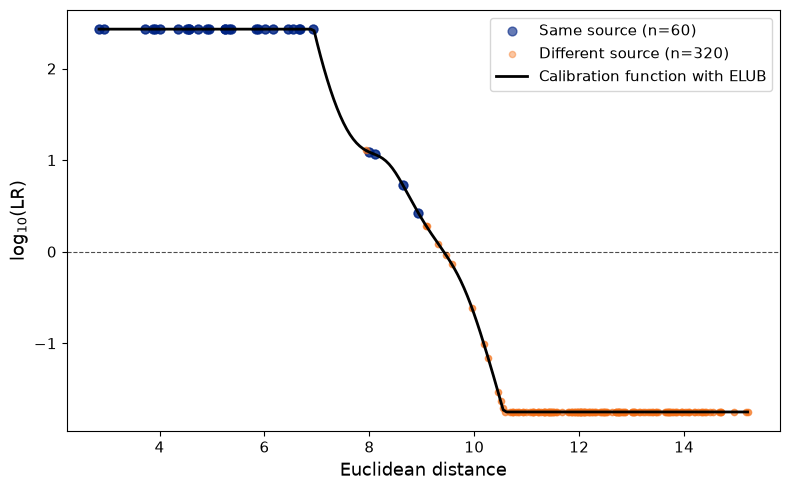

In [211]:
# Distance vs log10(LR) scatter plot using CV results
# Use the full-data calibrator (fitted on all pairs) to show the mapping curve,
# and overlay the CV distances colored by ground truth

# Fit calibrator on all pairwise distances (same as Step 5/6)
all_distances = np.concatenate([same_source, diff_source])
all_labels_dist = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
score_data_full = FeatureData(features=all_distances, labels=all_labels_dist)

cal_full = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
cal_full.fit(score_data_full)

# Get calibrated LRs for all distances
llr_all = cal_full.apply(score_data_full)

fig, ax = plt.subplots(figsize=(8, 5))

# Scatter: same-source
mask_same = all_labels_dist == 1
mask_diff = all_labels_dist == 0
ax.scatter(all_distances[mask_same], llr_all.features[mask_same],
           color=mycolors2[0], alpha=0.6, s=40, label=f'Same source (n={mask_same.sum()})')
ax.scatter(all_distances[mask_diff], llr_all.features[mask_diff],
           color=mycolors2[1], alpha=0.4, s=20, label=f'Different source (n={mask_diff.sum()})')

# Calibration curve: smooth mapping from distance → LR
d_range = np.linspace(all_distances.min(), all_distances.max(), 200)
d_fd = FeatureData(features=d_range)
llr_curve = cal_full.apply(d_fd)
ax.plot(d_range, llr_curve.features, 'k-', linewidth=2, label='Calibration function with ELUB')

# Reference line at log10(LR) = 0
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('Euclidean distance', fontsize=13)
ax.set_ylabel('log$_{10}$(LR)', fontsize=13)
#ax.set_title('Distance vs. Likelihood Ratio (KDE + ELUB calibrator)')
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)

#ax.figure.savefig('img/Distance_vs_LR1.svg', transparent=True)

plt.tight_layout()

# Report min and max LR obtainable with this system
min_llr = llr_curve.features.min()
max_llr = llr_curve.features.max()
print(f"LR range of this system (KDE + ELUB calibrator):")
print(f"  Min log10(LR) = {min_llr:.3f}  →  LR = {10**min_llr:.4f}")
print(f"  Max log10(LR) = {max_llr:.3f}  →  LR = {10**max_llr:.2f}")

#### Dataset 4

##### LR5

Cross-validated scores (leave-one-sample-out):
  Same-source pairs: 48
  Different-source pairs: 192

Cllr (KDE calibrator): 0.096


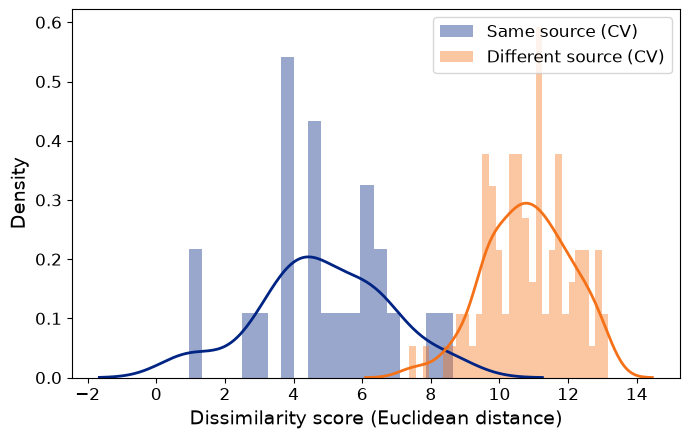

In [212]:
# Compute pairwise dissimilarity scores (Euclidean) with cross-validation
# Using leave-one-sample-out CV to avoid information leakage

# Aggregate: max area per compound for each Sample-Replicate
wt_dist = (widetable_DI_LR5_ref
    .reset_index()
    .groupby(['Category', 'Type', 'Sample', 'Replicate'])
    .max()
)
wt_dist = wt_dist.apply(lambda x: np.log10(x + 1))

samples_dist = wt_dist.index.get_level_values('Sample').values
unique_samples = np.unique(samples_dist)

# Leave-one-sample-out CV: for each fold, hold out one sample
# Compute scores for held-out pairs using distributions from training pairs
all_same_scores = []
all_diff_scores = []
cv_same_scores = []
cv_diff_scores = []

for held_out in unique_samples:
    # Split into train and test
    test_mask = samples_dist == held_out
    train_mask = ~test_mask
    
    train_data = wt_dist[train_mask]
    test_data = wt_dist[test_mask]
    train_samples = samples_dist[train_mask]
    
    # Compute distances between test replicates and all training replicates
    for i, (idx_test, row_test) in enumerate(test_data.iterrows()):
        # Same-source: distance between test replicate and other replicates of same sample
        other_test = test_data.drop(index=idx_test)
        for idx_other, row_other in other_test.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_other.values)**2))
            cv_same_scores.append(d)
        
        # Different-source: distance between test replicate and training replicates
        for idx_train, row_train in train_data.iterrows():
            d = np.sqrt(np.sum((row_test.values - row_train.values)**2))
            cv_diff_scores.append(d)

# Also compute full pairwise distances for comparison
dist_vec = pdist(wt_dist, metric='euclidean')
dist_mat = squareform(dist_vec)

n = len(samples_dist)
for i in range(n):
    for j in range(i + 1, n):
        d = dist_mat[i, j]
        if samples_dist[i] == samples_dist[j]:
            all_same_scores.append(d)
        else:
            all_diff_scores.append(d)

same_source = np.array(cv_same_scores)
diff_source = np.array(cv_diff_scores)

print(f"Cross-validated scores (leave-one-sample-out):")
print(f"  Same-source pairs: {len(same_source)}")
print(f"  Different-source pairs: {len(diff_source)}")

# Plot histogram + KDE
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(same_source, bins=20, density=True, alpha=0.4, color='#002484', label='Same source (CV)')
ax.hist(diff_source, bins=30, density=True, alpha=0.4, color='#f57118', label='Different source (CV)')

sns.kdeplot(same_source, ax=ax, color='#002484', linewidth=2)
sns.kdeplot(diff_source, ax=ax, color='#f57118', linewidth=2)

ax.set_xlabel('Dissimilarity score (Euclidean distance)', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
plt.tight_layout()

# Compute calibrated LRs using lir KDECalibrator (lir 1.6.0 API)
scores = np.concatenate([same_source, diff_source])
y_true = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])

# Create FeatureData with scores and labels
score_data = FeatureData(features=scores, labels=y_true)

# Fit KDE-based calibrator
cal = KDECalibrator(bandwidth='silverman')
cal.fit(score_data)

# Apply calibrator to get LLRs
llr_data = LLRData(**cal.apply(score_data).model_dump())

# Compute Cllr
cllr_value = compute_cllr(llr_data)
print(f"\nCllr (KDE calibrator): {cllr_value:.3f}")

#plt.savefig('img/dissimilarity_GCMS_hist_kde_CV_LR5.svg', transparent=True)

In [213]:
# === Step 6: Compare LR systems ===
# Using the CV dissimilarity scores computed above (same_source, diff_source)
# and SVM-based scores on DI-R paired data

# --- Prepare Euclidean distance score data ---
euclidean_scores = np.concatenate([same_source, diff_source])
euclidean_labels = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
euclidean_score_data = FeatureData(features=euclidean_scores, labels=euclidean_labels)

# --- Prepare SVM scores on DI-R pairs ---
# Create paired data from widetable_DI_R
wt_svm_lr = wt_dist.copy()
svm_source_ids = np.array(wt_svm_lr.index.get_level_values('Sample').values)

svm_features = wt_svm_lr.values
svm_fd = FeatureData(features=svm_features, source_ids=svm_source_ids)

instance_pairer = InstancePairing(ratio_limit=2)
svm_pairs = instance_pairer.pair(svm_fd)

# SVM pipeline: abs difference -> SVC -> probability to log odds
svm_scorer = LirPipeline([
    ('abs_difference', ElementWiseDifference()),
    ('classifier', SVC(probability=True)),
])
svm_scorer.fit(svm_pairs)
svm_score_data = svm_scorer.apply(svm_pairs)

print("=" * 60)
print("LR SYSTEM COMPARISON (Step 6)")
print("=" * 60)

# --- Define 4 LR systems ---
systems = {
    "Option 1: Euclidean + KDE": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 2: Euclidean + Logistic Regression": {
        "score_data": euclidean_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
    "Option 3: SVM + KDE": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('kde', KDECalibrator(bandwidth='silverman')), ('elub', ELUBBounder())])
    },
    "Option 4: SVM + Logistic Regression": {
        "score_data": svm_score_data,
        "calibrator": LirPipeline([('logreg', LogitCalibrator()), ('elub', ELUBBounder())])
    },
}

# --- Evaluate each system ---
for name, system in systems.items():
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    
    sd = system["score_data"]
    calibrator = system["calibrator"]
    
    # Fit and apply calibrator
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    
    # Compute Cllr
    cllr_val = compute_cllr(lrs)
    print(f"  Cllr: {cllr_val:.4f}")
    
    # # LR histogram
    # with show() as ax:
    #     ax.lr_histogram(lrs)
    #     ax.title(f'{name} - LR Histogram')
    
    # # PAV plot
    # with show() as ax:
    #     ax.pav(lrs)
    #     ax.title(f'{name} - PAV plot')

print(f"\n{'=' * 60}")
print("SUMMARY")
print(f"{'=' * 60}")
for name, system in systems.items():
    sd = system["score_data"]
    calibrator = system["calibrator"]
    lrs = LLRData(**calibrator.fit_apply(sd).model_dump())
    cllr_val = compute_cllr(lrs)
    print(f"  {name:<45} Cllr = {cllr_val:.4f}")

LR SYSTEM COMPARISON (Step 6)

──────────────────────────────────────────────────
  Option 1: Euclidean + KDE
──────────────────────────────────────────────────
  Cllr: 0.1127

──────────────────────────────────────────────────
  Option 2: Euclidean + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1163

──────────────────────────────────────────────────
  Option 3: SVM + KDE
──────────────────────────────────────────────────
  Cllr: 0.0447

──────────────────────────────────────────────────
  Option 4: SVM + Logistic Regression
──────────────────────────────────────────────────
  Cllr: 0.1895

SUMMARY
  Option 1: Euclidean + KDE                     Cllr = 0.1127
  Option 2: Euclidean + Logistic Regression     Cllr = 0.1163
  Option 3: SVM + KDE                           Cllr = 0.0447
  Option 4: SVM + Logistic Regression           Cllr = 0.1895


c:\Scripts\Icarus\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Leave-one-sample-out CV for Euclidean distance + KDE + ELUB
  Fold (held out: 184): 6 same-source, 48 different-source pairs
  Fold (held out: 356): 6 same-source, 48 different-source pairs
  Fold (held out: 433): 6 same-source, 48 different-source pairs
  Fold (held out: 561): 6 same-source, 48 different-source pairs

  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)
  Cllr (LOSO-CV): 0.3001
  Total pairs: 216 (same: 24, diff: 192)


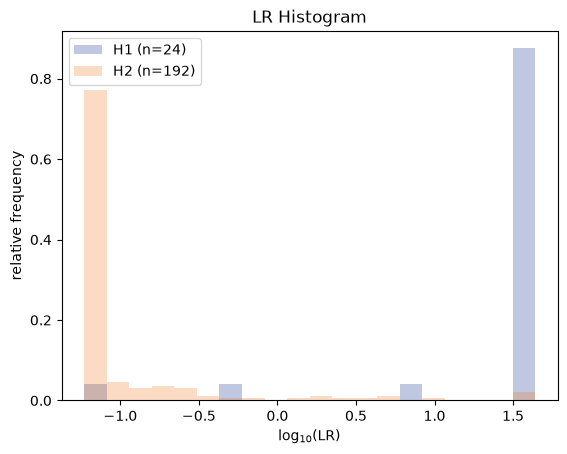

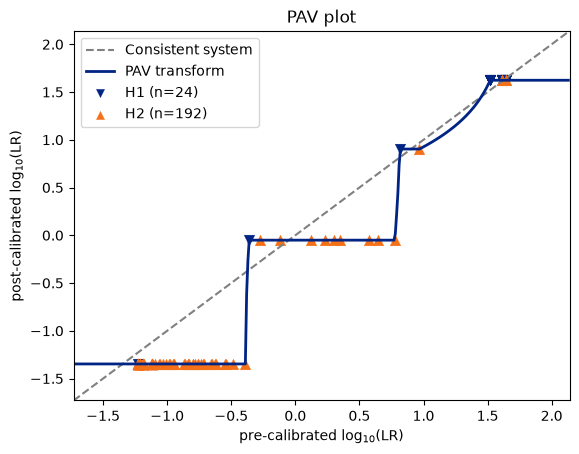

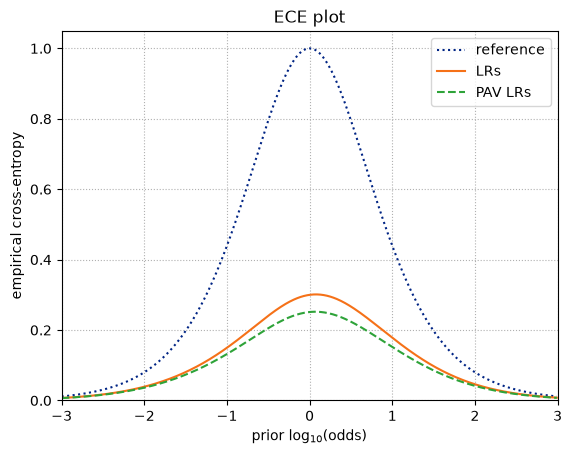

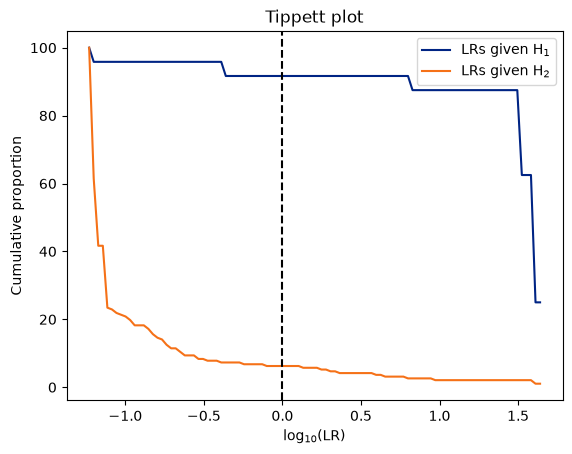

  Rates of misleading evidence:
    H1: 8.3% of same-source pairs have LR < 1 (misleading)
    H2: 6.2% of different-source pairs have LR >= 1 (misleading)


In [214]:
# === Step 7: Validate LR system (Option 1: Euclidean + KDE) ===
# Leave-one-sample-out CV: for each fold, hold out one sample entirely,
# compute Euclidean distance scores for held-out pairs, then fit KDE calibrator
# on training scores and apply to test scores. No classifier needed.

val_source_ids = np.array(wt_dist.index.get_level_values('Sample').values)
unique_samples_val = np.unique(val_source_ids)

all_cv_llrs = []
all_cv_labels = []

print("Leave-one-sample-out CV for Euclidean distance + KDE + ELUB")
print("=" * 60)

for held_out in unique_samples_val:
    # Split
    train_mask = val_source_ids != held_out
    test_mask = val_source_ids == held_out
    
    train_features = wt_dist.values[train_mask]
    train_ids = val_source_ids[train_mask]
    test_features = wt_dist.values[test_mask]
    n_test = test_features.shape[0]
    n_train = train_features.shape[0]
    
    # Compute training scores (Euclidean distances between training pairs)
    train_same_scores = []
    train_diff_scores = []
    for i in range(n_train):
        for j in range(i + 1, n_train):
            d = np.sqrt(np.sum((train_features[i] - train_features[j])**2))
            if train_ids[i] == train_ids[j]:
                train_same_scores.append(d)
            else:
                train_diff_scores.append(d)
    
    # Fit KDE + ELUB calibrator on training scores
    train_scores = np.concatenate([train_same_scores, train_diff_scores])
    train_labels = np.concatenate([
        np.ones(len(train_same_scores)),
        np.zeros(len(train_diff_scores))
    ])
    train_score_data = FeatureData(features=train_scores, labels=train_labels)
    
    calibrator_cv = LirPipeline([
        ('kde', KDECalibrator(bandwidth='silverman')),
        ('elub', ELUBBounder()),
    ])
    calibrator_cv.fit(train_score_data)
    
    # Compute test scores and apply fitted calibrator
    # Same-source: within held-out sample
    for i in range(n_test):
        for j in range(i + 1, n_test):
            d = np.sqrt(np.sum((test_features[i] - test_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([1]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(1)
    
    # Different-source: held-out vs training
    for i in range(n_test):
        for j in range(n_train):
            d = np.sqrt(np.sum((test_features[i] - train_features[j])**2))
            test_fd = FeatureData(features=np.array([d]), labels=np.array([0]))
            llr_result = calibrator_cv.apply(test_fd)
            all_cv_llrs.append(llr_result.features[0])
            all_cv_labels.append(0)
    
    n_same = n_test * (n_test - 1) // 2
    n_diff = n_test * n_train
    print(f"  Fold (held out: {held_out}): {n_same} same-source, {n_diff} different-source pairs")

# Combine all CV LRs
cv_llrs_euclidean = np.array(all_cv_llrs)
cv_labels_euclidean = np.array(all_cv_labels)
lrs_cv_euclidean = LLRData(features=cv_llrs_euclidean, labels=cv_labels_euclidean)

# Compute Cllr
cllr_cv_euclidean = compute_cllr(lrs_cv_euclidean)
print(f"\n{'=' * 60}")
print(f"  CROSS-VALIDATED RESULTS (Option 1: Euclidean + KDE + ELUB)")
print(f"{'=' * 60}")
print(f"  Cllr (LOSO-CV): {cllr_cv_euclidean:.4f}")
print(f"  Total pairs: {len(cv_llrs_euclidean)} (same: {cv_labels_euclidean.sum():.0f}, diff: {(1-cv_labels_euclidean).sum():.0f})")

# Override lir default plot colors with custom palette
_lir_plotting.H1_COLOR = mycolors2[0]
_lir_plotting.H2_COLOR = mycolors2[1]

# LR histogram
with show() as ax:
    ax.lr_histogram(lrs_cv_euclidean)
    ax.title('LR Histogram')
#    ax.figure.savefig('img/LR_histogram_LR5.svg', transparent=True)

# PAV plot
with show() as ax:
    ax.pav(lrs_cv_euclidean)
    for coll in ax.ax.collections:
        coll.set_sizes([60])
    ax.title('PAV plot')
#    ax.figure.savefig('img/PAV_plot_LR5.svg', transparent=True)

# ECE plot
with show() as ax:
    ax.ece(lrs_cv_euclidean)
    ax.title('ECE plot')
#    ax.figure.savefig('img/ECE_plot_LR5.svg', transparent=True)

# Tippett plot (uses hardcoded 'b'/'r', override manually)
with show() as ax:
    llrs_t = lrs_cv_euclidean.llrs
    labels_t = lrs_cv_euclidean.require_labels
    lr_0, lr_1 = _lir_util.Xy_to_Xn(llrs_t, labels_t)
    xvalues = np.linspace(np.min(llrs_t[np.isfinite(llrs_t)]), np.max(llrs_t[np.isfinite(llrs_t)]), 100)
    perc0 = (sum(i >= xvalues for i in lr_0) / len(lr_0)) * 100
    perc1 = (sum(i >= xvalues for i in lr_1) / len(lr_1)) * 100
    ax.ax.plot(xvalues, perc1, color=mycolors2[0], label=r'LRs given $\mathregular{H_1}$')
    ax.ax.plot(xvalues, perc0, color=mycolors2[1], label=r'LRs given $\mathregular{H_2}$')
    ax.ax.axvline(x=0, color='k', linestyle='--')
    ax.ax.set_xlabel('log$_{10}$(LR)')
    ax.ax.set_ylabel('Cumulative proportion')    
    ax.ax.legend()        
    ax.title('Tippett plot')
#    ax.figure.savefig('img/Tippett_plot_LR5.svg', transparent=True)

# Rates of misleading evidence at log10(LR) = 0
prop_h1_at_0 = (np.sum(lr_1 >= 0) / len(lr_1)) * 100
prop_h2_at_0 = (np.sum(lr_0 >= 0) / len(lr_0)) * 100
print(f"  Rates of misleading evidence:")
print(f"    H1: {100 - prop_h1_at_0:.1f}% of same-source pairs have LR < 1 (misleading)")
print(f"    H2: {prop_h2_at_0:.1f}% of different-source pairs have LR >= 1 (misleading)")

Fit the selected LR system (Euclidean distance + KDE + ELUB) on all available reference data, then apply it to the casework observations to obtain LRs.

- **Observation 1**: 
- **Observation 2**: 

In [215]:
# === Step 8: Construct casework LR system ===
# Fit Euclidean + KDE + ELUB on ALL background reference data (wt_dist = DI-R)
# Then apply to casework observation pair (x)

# --- 1. Fit calibrator on all pairwise Euclidean distances from background data ---
bg_samples = wt_dist.index.get_level_values('Sample').values
bg_features = wt_dist.values
n_bg = len(bg_features)

bg_same_scores = []
bg_diff_scores = []
for i in range(n_bg):
    for j in range(i + 1, n_bg):
        d = np.sqrt(np.sum((bg_features[i] - bg_features[j])**2))
        if bg_samples[i] == bg_samples[j]:
            bg_same_scores.append(d)
        else:
            bg_diff_scores.append(d)

bg_scores = np.concatenate([bg_same_scores, bg_diff_scores])
bg_labels = np.concatenate([np.ones(len(bg_same_scores)), np.zeros(len(bg_diff_scores))])
bg_score_data = FeatureData(features=bg_scores, labels=bg_labels)

# Fit the casework LR system (KDE + ELUB) on all background scores
casework_lr_system = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
casework_lr_system.fit(bg_score_data)

print("Casework LR system fitted on all DI-R background data")
print(f"  Background pairs: {len(bg_same_scores)} same-source, {len(bg_diff_scores)} different-source")

# --- 2. Prepare casework observations ---
# Align columns: use same features as background (wt_dist)
shared_cols = wt_dist.columns.intersection(widetable_DI_LR5.columns)

# Casework observations with log10 transform (matching background)
casework_data = widetable_DI_LR5[shared_cols].apply(lambda x: np.log10(x + 1))

obs1 = casework_data.xs('067', level='Sample')  # Observation 1: sample 067
obs2 = casework_data.xs('893', level='Sample')  # Observation 2: sample 893

print(f"\n  Observation 1 (sample 067): {len(obs1)} replicates")
print(f"  Observation 2 (sample 893): {len(obs2)} replicates")
print(f"  Shared features: {len(shared_cols)}")

# --- 3. Compute Euclidean distances between all pairs of replicates ---
casework_distances = []
pair_labels = []

for i, (idx1, row1) in enumerate(obs1.iterrows()):
    for j, (idx2, row2) in enumerate(obs2.iterrows()):
        d = np.sqrt(np.sum((row1.values - row2.values)**2))
        rep1 = idx1[-1] if isinstance(idx1, tuple) else idx1
        rep2 = idx2[-1] if isinstance(idx2, tuple) else idx2
        casework_distances.append(d)
        pair_labels.append(f"356_rep{rep1} vs 876_rep{rep2}")

casework_distances = np.array(casework_distances)

# --- 4. Apply the fitted LR system to get LRs ---
casework_fd = FeatureData(features=casework_distances, labels=np.ones(len(casework_distances)))
casework_llr_data = casework_lr_system.apply(casework_fd)
casework_llrs = casework_llr_data.features.flatten()  # log10(LR) values
casework_lrs = 10**casework_llrs  # Convert log10LR to LR

print(f"\n{'=' * 60}")
print(f"  CASEWORK LR RESULTS (Sample 356 vs Sample 876)")
print(f"{'=' * 60}")
print(f"  {'Pair':<30} {'Distance':>10} {'log10(LR)':>10} {'LR':>12}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*12}")
for label, dist, llr, lr in zip(pair_labels, casework_distances, casework_llrs, casework_lrs):
    print(f"  {label:<30} {dist:>10.3f} {llr:>10.3f} {lr:>12.3f}")

# Summary statistics
mean_llr = np.mean(casework_llrs)
median_llr = np.median(casework_llrs)
print(f"\n  Summary:")
print(f"  Mean log10(LR):   {mean_llr:.3f}  (LR = {10**mean_llr:.3f})")
print(f"  Median log10(LR): {median_llr:.3f}  (LR = {10**median_llr:.3f})")

Casework LR system fitted on all DI-R background data
  Background pairs: 24 same-source, 96 different-source

  Observation 1 (sample 067): 4 replicates
  Observation 2 (sample 893): 4 replicates
  Shared features: 20

  CASEWORK LR RESULTS (Sample 356 vs Sample 876)
  Pair                             Distance  log10(LR)           LR
  ------------------------------ ---------- ---------- ------------
  356_rep1 vs 876_rep1               11.701     -1.260        0.055
  356_rep1 vs 876_rep2               11.774     -1.260        0.055
  356_rep1 vs 876_rep3               11.798     -1.260        0.055
  356_rep1 vs 876_rep4               11.665     -1.260        0.055
  356_rep2 vs 876_rep1               11.872     -1.260        0.055
  356_rep2 vs 876_rep2               11.429     -1.260        0.055
  356_rep2 vs 876_rep3               11.462     -1.260        0.055
  356_rep2 vs 876_rep4               12.115     -1.260        0.055
  356_rep3 vs 876_rep1               11.145     -1.

LR range of this system (KDE + ELUB calibrator):
  Min log10(LR) = -1.540  →  LR = 0.0288
  Max log10(LR) = 2.170  →  LR = 147.91


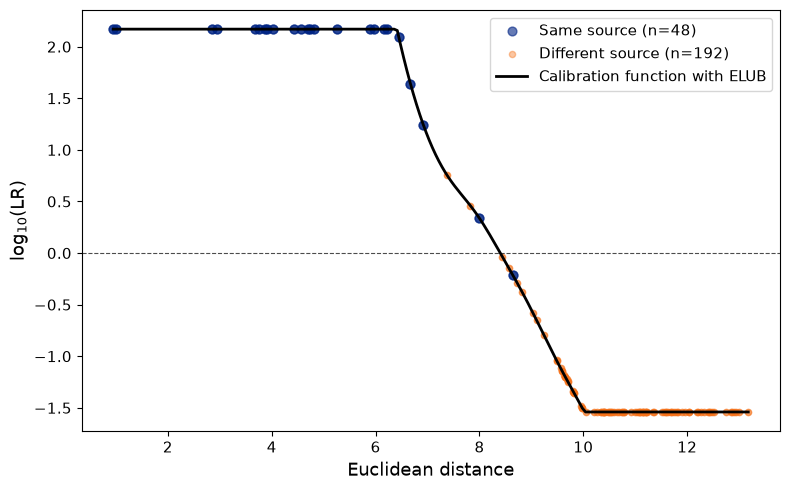

In [216]:
# Distance vs log10(LR) scatter plot using CV results
# Use the full-data calibrator (fitted on all pairs) to show the mapping curve,
# and overlay the CV distances colored by ground truth

# Fit calibrator on all pairwise distances (same as Step 5/6)
all_distances = np.concatenate([same_source, diff_source])
all_labels_dist = np.concatenate([np.ones(len(same_source)), np.zeros(len(diff_source))])
score_data_full = FeatureData(features=all_distances, labels=all_labels_dist)

cal_full = LirPipeline([
    ('kde', KDECalibrator(bandwidth='silverman')),
    ('elub', ELUBBounder()),
])
cal_full.fit(score_data_full)

# Get calibrated LRs for all distances
llr_all = cal_full.apply(score_data_full)

fig, ax = plt.subplots(figsize=(8, 5))

# Scatter: same-source
mask_same = all_labels_dist == 1
mask_diff = all_labels_dist == 0
ax.scatter(all_distances[mask_same], llr_all.features[mask_same],
           color=mycolors2[0], alpha=0.6, s=40, label=f'Same source (n={mask_same.sum()})')
ax.scatter(all_distances[mask_diff], llr_all.features[mask_diff],
           color=mycolors2[1], alpha=0.4, s=20, label=f'Different source (n={mask_diff.sum()})')

# Calibration curve: smooth mapping from distance → LR
d_range = np.linspace(all_distances.min(), all_distances.max(), 200)
d_fd = FeatureData(features=d_range)
llr_curve = cal_full.apply(d_fd)
ax.plot(d_range, llr_curve.features, 'k-', linewidth=2, label='Calibration function with ELUB')

# Reference line at log10(LR) = 0
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('Euclidean distance', fontsize=13)
ax.set_ylabel('log$_{10}$(LR)', fontsize=13)
#ax.set_title('Distance vs. Likelihood Ratio (KDE + ELUB calibrator)')
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)

#ax.figure.savefig('img/Distance_vs_LR1.svg', transparent=True)

plt.tight_layout()

# Report min and max LR obtainable with this system
min_llr = llr_curve.features.min()
max_llr = llr_curve.features.max()
print(f"LR range of this system (KDE + ELUB calibrator):")
print(f"  Min log10(LR) = {min_llr:.3f}  →  LR = {10**min_llr:.4f}")
print(f"  Max log10(LR) = {max_llr:.3f}  →  LR = {10**max_llr:.2f}")